<a href="https://colab.research.google.com/github/shazee-a/Sleep-Healthy-Classifier/blob/main/UAS_Sleep_Health_Kelompok_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Data Sains — Analisis Sleep Health and Lifestyle Dataset

**Kelompok:** _(kelompok 6)_

**Anggota:**
1. _(Zaky Alfatih)_ — Data Cleaning
2. _(Fakhri Wahyu Insani)_ — EDA & Visualisasi
3. _(Rifana Rachmadilla & Zaky Alfatih)_ — Feature Engineering & Preprocessing
4. _(Shaquilla Azizah & Fadli Ghafatul Hijriah)_ — Modeling & Evaluasi
5. _(Fadli Ghafatul Hijriah)_ — Kesimpulan

---

#### Job Desk dari masing-masing anggota mengerjakan sesuai sectionnya masing-masing

#### Setiap anggota melakukan analisis dari setiap section yang dikerjakan oleh temannya

#### Untuk Section 2 karena butuh hasil Section 1 & 2 selesai dulu, Section 4 butuh Section 3 selesai, dst.




In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


---
## SECTION 0 — Setup (Import Package yang dibutuhkan)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print ("Library Aman")

Library Aman


In [ ]:
import pandas as pd

# Upload file CSV ke Colab
# lalu sesuaikan nama file di bawah ini.

# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')


df_mentah= pd.read_csv("/content/drive/MyDrive/Tubes_Data_Science_Kelompok_6/Data_File/Sleep_health_and_lifestyle_dataset.csv")
df_mentah.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


---
## 👤 SECTION 1 — Membersihkan Data Mentah (Cleaning data awal)
**Dikerjakan Oleh: _(Zaky Alfatih)_**

### Tugas:
- Membersihkan data mentah dan disimpan menjadi variabel df_Bersih
- Cek Outlier
- Hapus data Duplikat
- Cek Missing value dan isi dengan fillna
- dll

In [ ]:
#Cek missing Values
print(df_mentah.isnull().sum())
df_mentah.columns = df_mentah.columns.str.strip()

#Mengisi missing value pada kolom Sleep Disorder dengan "No Disorder"
df_mentah['Sleep Disorder'] = df_mentah['Sleep Disorder'].fillna('No Disorder')
df_mentah.head()

Person ID                   0
 Gender                     0
 Age                        0
 Occupation                 0
 Sleep Duration             0
 Quality of Sleep           0
 Physical Activity Level    0
 Stress Level               0
 BMI Category               0
 Blood Pressure             0
 Heart Rate                 0
 Daily Steps                0
 Sleep Disorder             0
dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# Memecah Blood Pressure menjadi dua kolom baru
df_mentah.columns = df_mentah.columns.str.strip()

if 'Blood Pressure' in df_mentah.columns:
    df_mentah[['BP Systolic', 'BP Diastolic']] = df_mentah['Blood Pressure'].str.split('/', expand=True).astype(float)
else:
    print("Column 'Blood Pressure' not found. It might have been processed already or renamed.")

In [ ]:
def ketegorisasi_bp(row):
    sys = row['BP Systolic']
    dia = row['BP Diastolic']

    if sys > 180 or dia > 120:
        return 'Hypertensive Crisis'
    elif sys >= 140 or dia >= 90:
        return 'Hypertension Stage 2'
    elif (130 <= sys <= 139) or (80 <= dia <= 89):
        return 'Hypertension Stage 1'
    elif sys >= 120 and sys <= 129 and dia < 80:
        return 'Elevated'
    elif sys < 120 and dia < 80:=================
        return 'Normal'
    else:
        return 'Hypertension Stage 1' # Antisipasi jika ada irisan data lain

In [ ]:
df_mentah['Blood Pressure'] = df_mentah.apply(ketegorisasi_bp, axis=1)

In [ ]:
df_mentah = df_mentah.rename(columns={'Blood Pressure': 'BP Category'})

In [ ]:
#Menghapus semua spasi kanan-kiri di kolom teks
df_mentah['Sleep Disorder'] = df_mentah['Sleep Disorder'].str.strip()
df_mentah['BMI Category'] = df_mentah['BMI Category'].str.strip()

In [ ]:
#Replace kata di kolom sleep disorder & bmi category
df_mentah['Sleep Disorder'] = df_mentah['Sleep Disorder'].replace('None', 'No Disorder')
df_mentah['BMI Category'] = df_mentah['BMI Category'].replace('Normal Weight', 'Normal')

In [ ]:
#Cek nilai unik
print("Nilai unik Sleep Disorder:", df_mentah['Sleep Disorder'].unique())
print("Nilai unik BMI Category:", df_mentah['BMI Category'].unique())
df_mentah.head()



Nilai unik Sleep Disorder: ['No Disorder' 'Sleep Apnea' 'Insomnia']
Nilai unik BMI Category: ['Overweight' 'Normal' 'Obese']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,BP Category,Heart Rate,Daily Steps,Sleep Disorder,BP Systolic,BP Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,Hypertension Stage 1,77,4200,No Disorder,126.0,83.0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,Hypertension Stage 1,75,10000,No Disorder,125.0,80.0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,Hypertension Stage 1,75,10000,No Disorder,125.0,80.0
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,Hypertension Stage 2,85,3000,Sleep Apnea,140.0,90.0
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,Hypertension Stage 2,85,3000,Sleep Apnea,140.0,90.0


In [ ]:
#Menghapus data duplikat dan simpan di variabel baru
df_clean = df_mentah.drop_duplicates(keep='first').copy()

In [ ]:
#hitung rumus iqr /outlier
Q1 = df_clean['Heart Rate'].quantile(0.25)
Q3 = df_clean['Heart Rate'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


print(f"Nilai Q1 (25%): {Q1}")
print(f"Nilai Q3 (75%): {Q3}")
print(f"Nilai IQR: {IQR}")
print(f"Batas Bawah Antara: {lower_bound}")
print(f"Batas Atas Antara: {upper_bound}")

Nilai Q1 (25%): 68.0
Nilai Q3 (75%): 72.0
Nilai IQR: 4.0
Batas Bawah Antara: 62.0
Batas Atas Antara: 78.0


In [ ]:
#cek jumlah data yang diluar batas/cek outlier
df_outlier = df_clean[(df_clean['Heart Rate'] < lower_bound) | (df_clean['Heart Rate'] > upper_bound)]

jumlah_outlier = df_outlier.shape[0]

print(f"Jumlah data outlier di kolom Heart Rate: {jumlah_outlier} baris")
print("-" * 50)

if jumlah_outlier > 0:
    print("Berikut adalah data yang terdeteksi outlier:")
    print(df_outlier[['Person ID', 'Heart Rate', 'Sleep Disorder']].head())
else:
    print("Aman, tidak ada data outlier!")

Jumlah data outlier di kolom Heart Rate: 15 baris
--------------------------------------------------
Berikut adalah data yang terdeteksi outlier:
    Person ID  Heart Rate Sleep Disorder
3           4          85    Sleep Apnea
4           5          85    Sleep Apnea
5           6          85       Insomnia
6           7          82       Insomnia
16         17          80    Sleep Apnea


In [ ]:
#Menghitung Nilai rata rata dari Kolom "Heart Rate"
nilai_mean = df_clean['Heart Rate'].mean()
print(f"Nilai rata-rata Heart Rate: {nilai_mean:.2f}")

#Melakukan imputasi JIKA diluar batas ganti dengan nilai Mean(RATA RATA)
df_clean['Heart Rate'] = df_clean['Heart Rate'].apply(
    lambda x: nilai_mean if (x < lower_bound or x > upper_bound) else x
)

print("Imputasi selesai!")
print("-" * 50)

#Mengecek apakah masih ada data outlier w

outlier_setelah = df_clean[(df_clean['Heart Rate'] < lower_bound) | (df_clean['Heart Rate'] > upper_bound)].shape[0]
print(f"Jumlah outlier di kolom Heart Rate sekarang: {outlier_setelah} baris")

Nilai rata-rata Heart Rate: 70.17
Imputasi selesai!
--------------------------------------------------
Jumlah outlier di kolom Heart Rate sekarang: 0 baris


In [ ]:
#Menampilkan Informasi Data dari setiap column
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   BP Category              374 non-null    object 
 10  Heart Rate               374 non-null    float64
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
 13  BP Systolic              374 non-null    float64
 14  BP Diastolic             3

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP Systolic,BP Diastolic
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,69.651034,6816.844920,128.553476,84.649733
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,3.167304,1617.915679,7.748118,6.161611
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,78.000000,10000.000000,142.000000,95.000000


In [ ]:
#Menampilkan seluruh isi data yang telah dibersihkan
import pandas as pd
pd.set_option('display.max_rows', None)

df_clean

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,BP Category,Heart Rate,Daily Steps,Sleep Disorder,BP Systolic,BP Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,Hypertension Stage 1,77.000000,4200,No Disorder,126.0,83.0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,Hypertension Stage 1,75.000000,10000,No Disorder,125.0,80.0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,Hypertension Stage 1,75.000000,10000,No Disorder,125.0,80.0
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,Hypertension Stage 2,70.165775,3000,Sleep Apnea,140.0,90.0
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,Hypertension Stage 2,70.165775,3000,Sleep Apnea,140.0,90.0
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,Hypertension Stage 2,70.165775,3000,Insomnia,140.0,90.0
6,7,Male,29,Teacher,6.3,6,40,7,Obese,Hypertension Stage 2,70.165775,3500,Insomnia,140.0,90.0
7,8,Male,29,Doctor,7.8,7,75,6,Normal,Hypertension Stage 1,70.000000,8000,No Disorder,120.0,80.0
8,9,Male,29,Doctor,7.8,7,75,6,Normal,Hypertension Stage 1,70.000000,8000,No Disorder,120.0,80.0
9,10,Male,29,Doctor,7.8,7,75,6,Normal,Hypertension Stage 1,70.000000,8000,No Disorder,120.0,80.0


In [ ]:
#Menyimpan hasil akhir nya ke variabel "df_clean"
df_Bersih = df_clean.copy()

print("Data Cleaning Selesai! Variabel df_Bersih siap digunakan untuk Section 2.")

Data Cleaning Selesai! Variabel df_Bersih siap digunakan untuk Section 2.


---
## 👤 SECTION 2 — Membuat Visualisasi dari data mentah dan data bersih lalu tulis kesimpulan dari tiap visual dan kesimpulan akhir yang didapat
**Dikerjakan Oleh: _(Fakhri Wahyu Insani)_**

### Tugas:
- Membuat Visual dari data mentah seperti tugas EDA analisis sebelumnya
- Membuat visualisasi dari dataset data bersih (df_bersih)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean nama kolom dari spasi yang tidak terlihat
df_mentah.columns = df_mentah.columns.str.strip()

# Set gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10

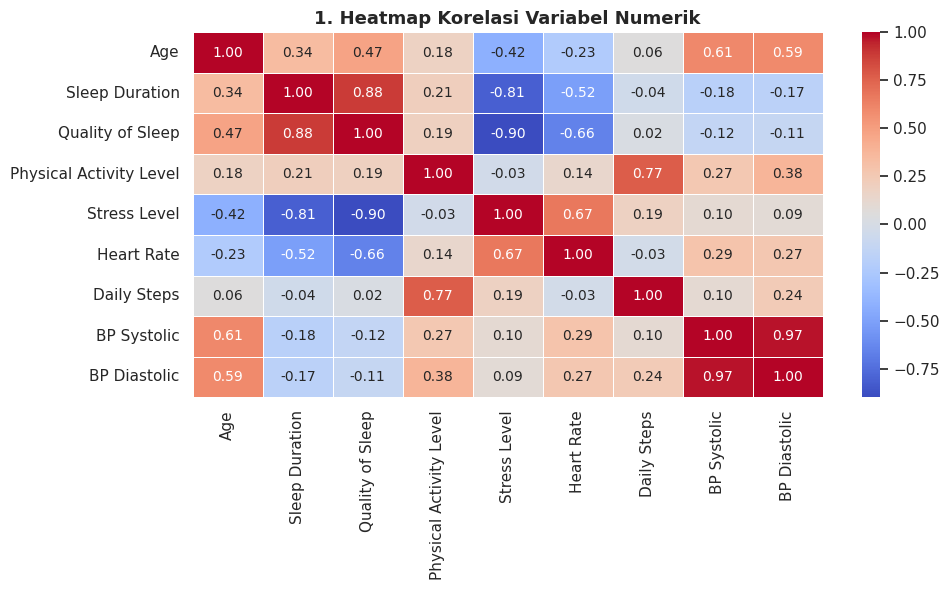

In [ ]:
#Heat Map
plt.figure(figsize=(10, 6))

# Pilih kolom numerik selain 'Person ID'
numeric_cols = df_mentah.select_dtypes(include=["number"]).columns.drop('Person ID', errors='ignore')
correlation_matrix = df_mentah[numeric_cols].corr()

# Tampilkan heatmap tanpa Person ID
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("1. Heatmap Korelasi Variabel Numerik", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

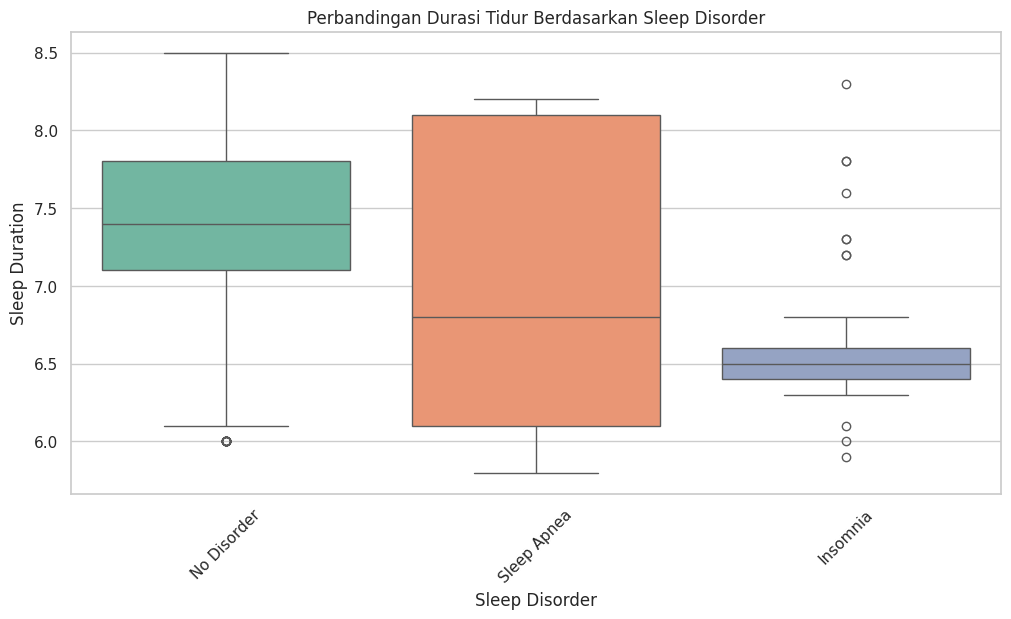

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sleep Disorder', y='Sleep Duration', data=df_mentah, palette='Set2', hue='Sleep Disorder')
plt.xticks(rotation=45)
plt.title('Perbandingan Durasi Tidur Berdasarkan Sleep Disorder')
plt.show()

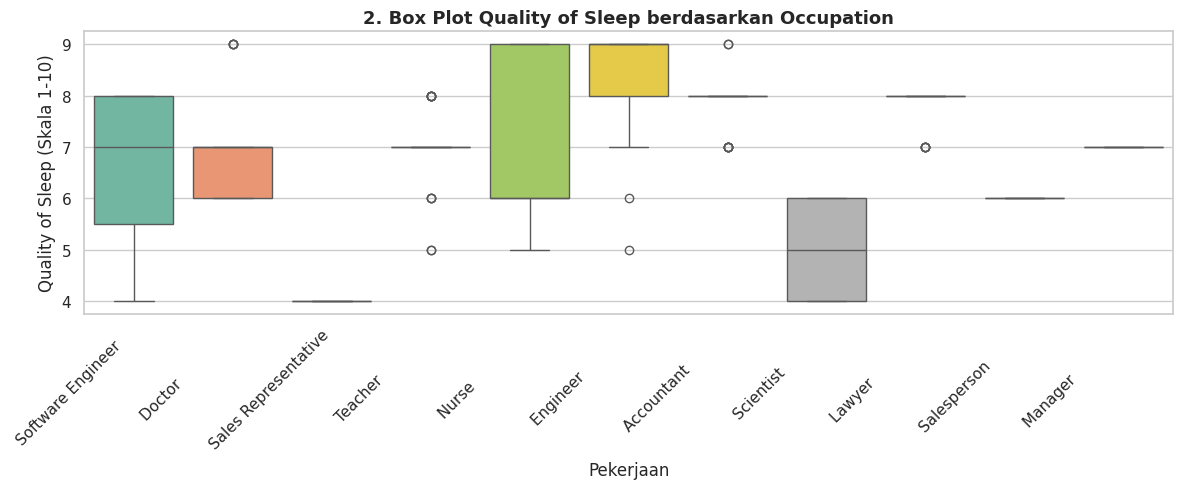

In [ ]:
# Box Plot
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_mentah, x="Occupation", y="Quality of Sleep", palette="Set2", legend=False)
plt.title("2. Box Plot Quality of Sleep berdasarkan Occupation", fontsize=13, fontweight="bold")
plt.xlabel("Pekerjaan")
plt.ylabel("Quality of Sleep (Skala 1-10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

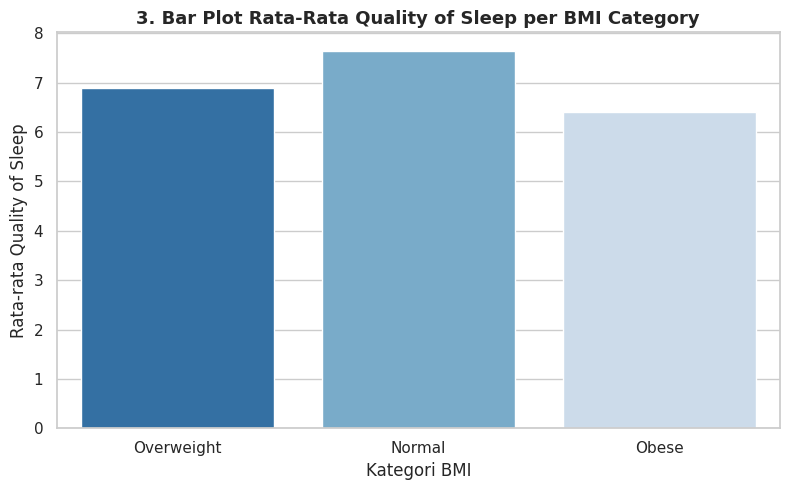

In [ ]:
#Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df_mentah, x="BMI Category", y="Quality of Sleep", palette="Blues_r", errorbar=None)
plt.title("3. Bar Plot Rata-Rata Quality of Sleep per BMI Category", fontsize=13, fontweight="bold")
plt.xlabel("Kategori BMI")
plt.ylabel("Rata-rata Quality of Sleep")
plt.tight_layout()
plt.show()


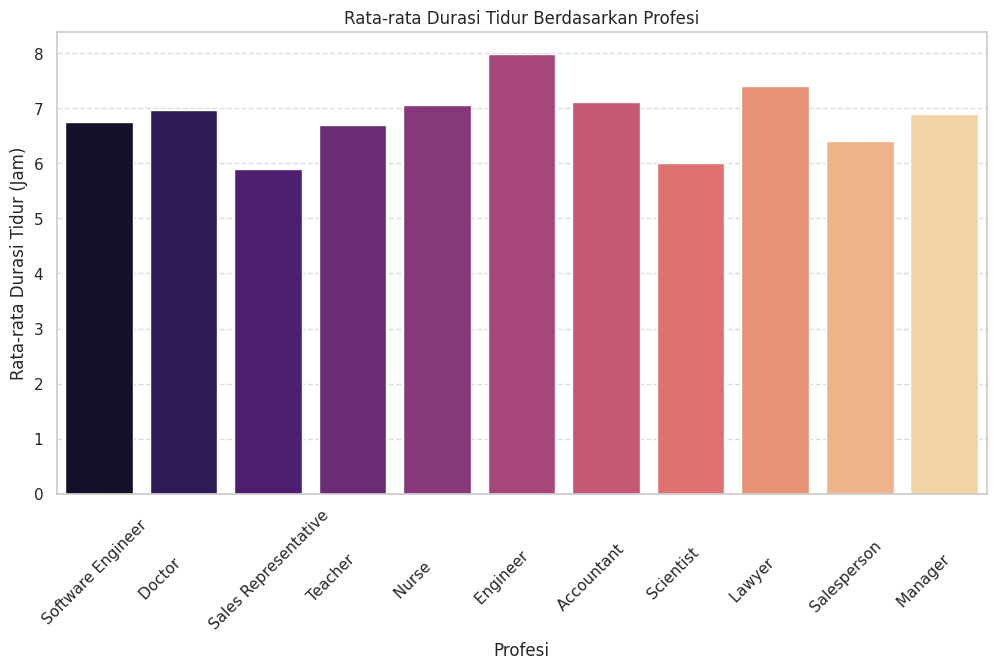

In [ ]:
# Visualisasi Bar Chart: Rata-rata Durasi Tidur per Profesi
plt.figure(figsize=(12, 6))

# x = kategori (Profesi)
# y = nilai yang mau dihitung (Durasi Tidur)
# Secara default sns.barplot bakal nampilin RATA-RATA (mean)
sns.barplot(x='Occupation', y='Sleep Duration', data=df_mentah, palette='magma', ci=None)

plt.title('Rata-rata Durasi Tidur Berdasarkan Profesi')
plt.xlabel('Profesi')
plt.ylabel('Rata-rata Durasi Tidur (Jam)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Tambahin garis biar gampang bacanya
plt.show()

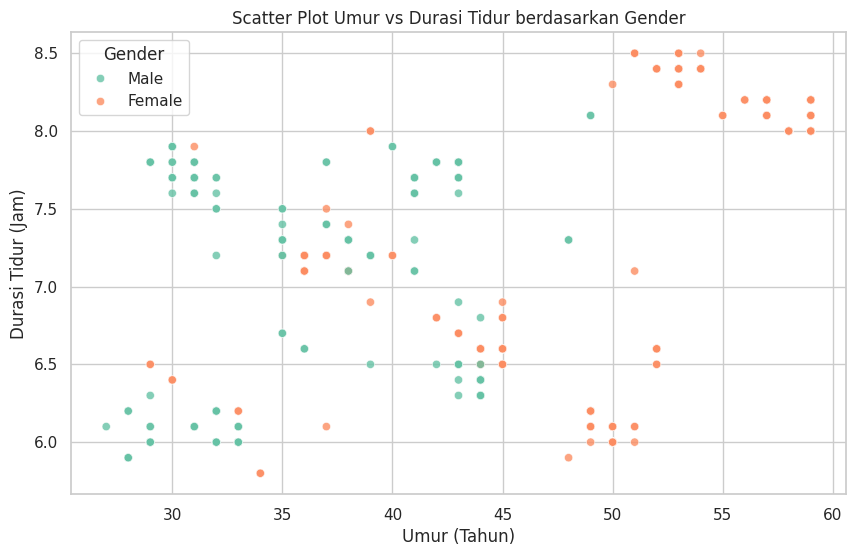

In [ ]:
# SCATTER PLOT
plt.figure(figsize=(10, 6))

# Kita langsung bersihkan spasi nama kolom & datanya di sini
df_mentah.columns = df_mentah.columns.str.strip()

sns.scatterplot(
    data=df_mentah,
    x='Age',
    y='Sleep Duration',
    hue=df_mentah['Gender'].str.strip(),  # Langsung di-strip di dalam sini
    palette='Set2',
    alpha=0.8
)

plt.title('Scatter Plot Umur vs Durasi Tidur berdasarkan Gender')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Durasi Tidur (Jam)')
plt.show()


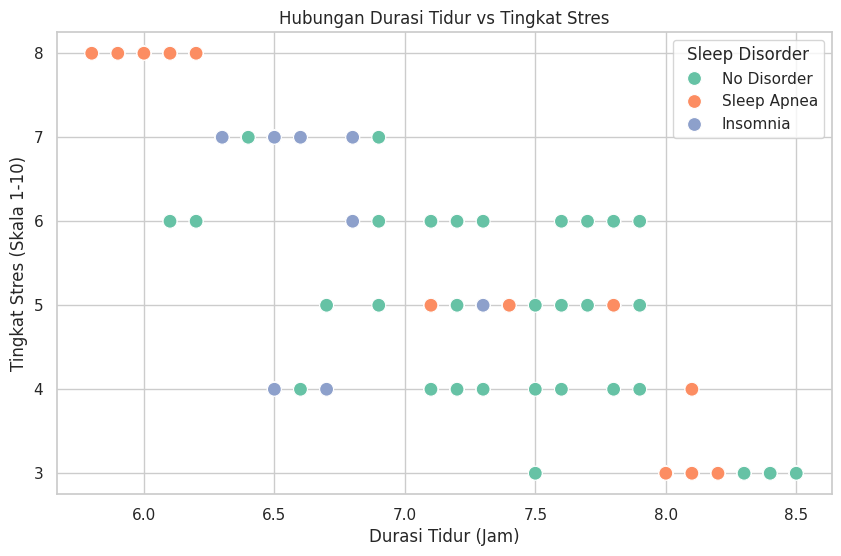

In [ ]:
# 1. Relasi antara durasi tidur dan tingkat stres, dengan warna berdasarkan Sleep Disorder
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_mentah['Sleep Duration'], y=df_mentah['Stress Level'], hue='Sleep Disorder', data=df_mentah, palette='Set2', s=100,)
plt.title('Hubungan Durasi Tidur vs Tingkat Stres')
plt.xlabel('Durasi Tidur (Jam)')
plt.ylabel('Tingkat Stres (Skala 1-10)')
plt.show()

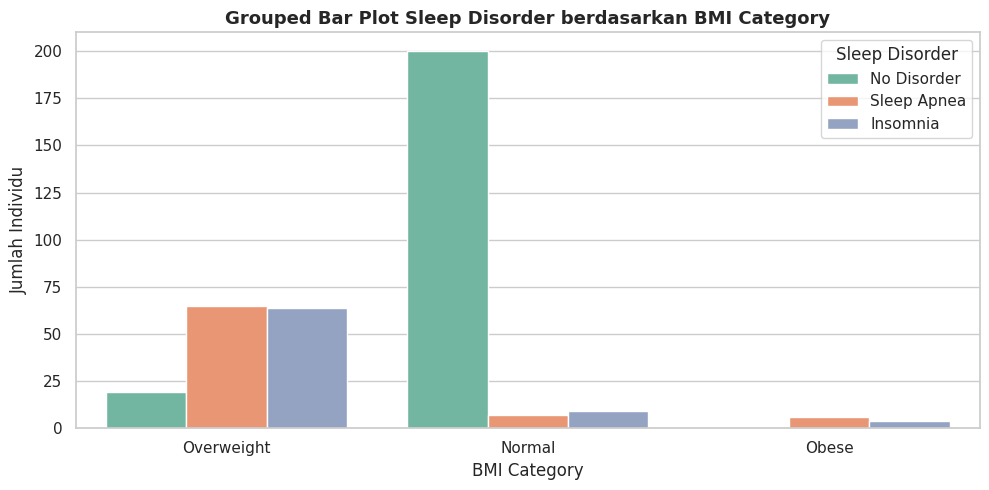

In [ ]:
#GROUPED BAR PLOT (Sleep Disorder per BMI Category)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_mentah, x="BMI Category", hue="Sleep Disorder", palette="Set2")
plt.title("Grouped Bar Plot Sleep Disorder berdasarkan BMI Category", fontsize=13, fontweight="bold")
plt.xlabel("BMI Category")
plt.ylabel("Jumlah Individu")
plt.legend(title="Sleep Disorder")
plt.tight_layout()
plt.show()

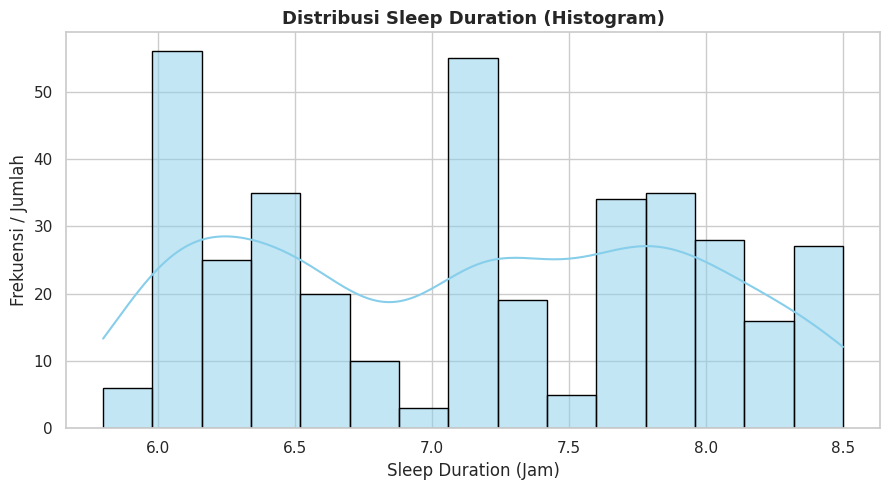

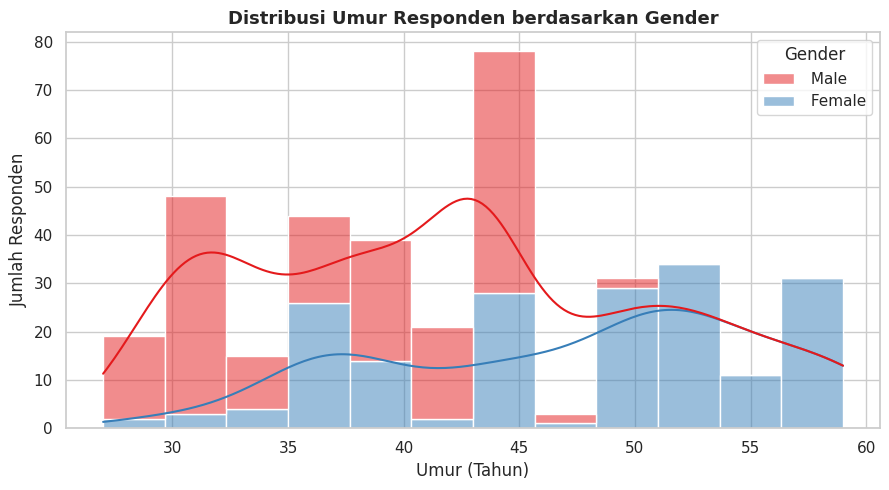

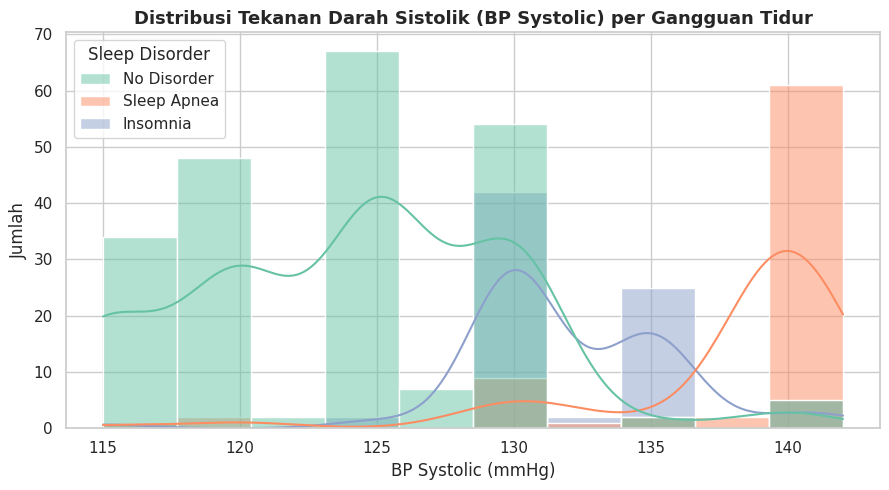

In [ ]:
#HISTOGRAM (DISTRIBUSI DATA NUMERIK)
# ------------------------------------------
# HISTOGRAM 1: Distribusi Sleep Duration dengan KDE Line
# ------------------------------------------
plt.figure(figsize=(9, 5))
sns.histplot(data=df_mentah, x="Sleep Duration", kde=True, bins=15, color="skyblue", edgecolor="black")
plt.title("Distribusi Sleep Duration (Histogram)", fontsize=13, fontweight="bold")
plt.xlabel("Sleep Duration (Jam)")
plt.ylabel("Frekuensi / Jumlah")
plt.tight_layout()
plt.show()

# ------------------------------------------
# HISTOGRAM 2: Distribusi Age berdasarkan Gender
# ------------------------------------------
plt.figure(figsize=(9, 5))
sns.histplot(data=df_mentah, x="Age", hue="Gender", kde=True, bins=12, palette="Set1", multiple="stack")
plt.title("Distribusi Umur Responden berdasarkan Gender", fontsize=13, fontweight="bold")
plt.xlabel("Umur (Tahun)")
plt.ylabel("Jumlah Responden")
plt.tight_layout()
plt.show()

# ------------------------------------------
# HISTOGRAM 3: Distribusi BP Systolic berdasarkan Sleep Disorder
# ------------------------------------------
if "BP Systolic" in df_mentah.columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=df_mentah, x="BP Systolic", hue="Sleep Disorder", kde=True, bins=10, palette="Set2")
    plt.title("Distribusi Tekanan Darah Sistolik (BP Systolic) per Gangguan Tidur", fontsize=13, fontweight="bold")
    plt.xlabel("BP Systolic (mmHg)")
    plt.ylabel("Jumlah")
    plt.tight_layout()
    plt.show()

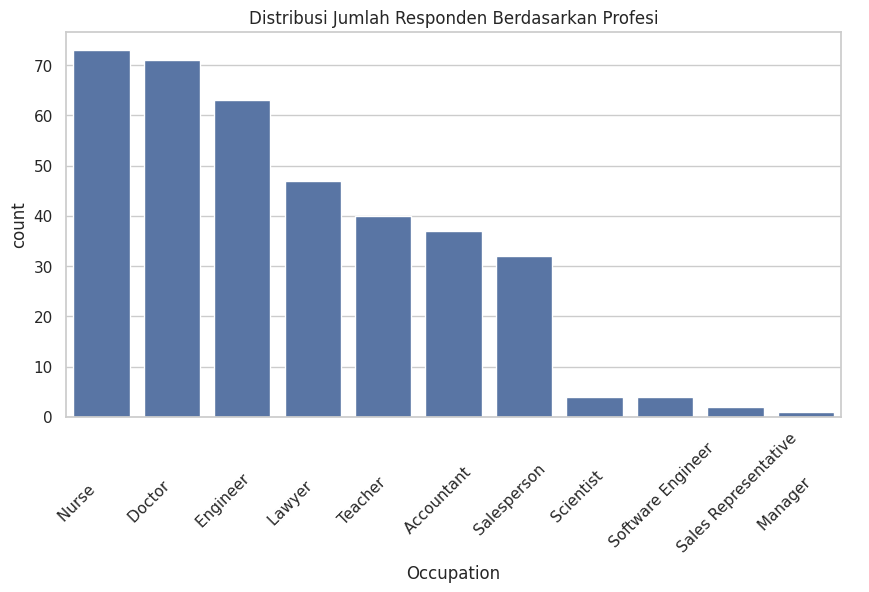

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_mentah, x='Occupation', order=df_mentah['Occupation'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribusi Jumlah Responden Berdasarkan Profesi')
plt.show()

In [ ]:
# Melihat rangkuman statistik data numerik (Mean, Min, Max, dll)
df_mentah.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP Systolic,BP Diastolic
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


In [ ]:
# Visual EDA Data setelah bersih
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan nama kolom tidak ada spasi di awal/akhir
df_clean.columns = df_clean.columns.str.strip()

# Atur gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 10
# Cek Outlier, dan lain lain lagi

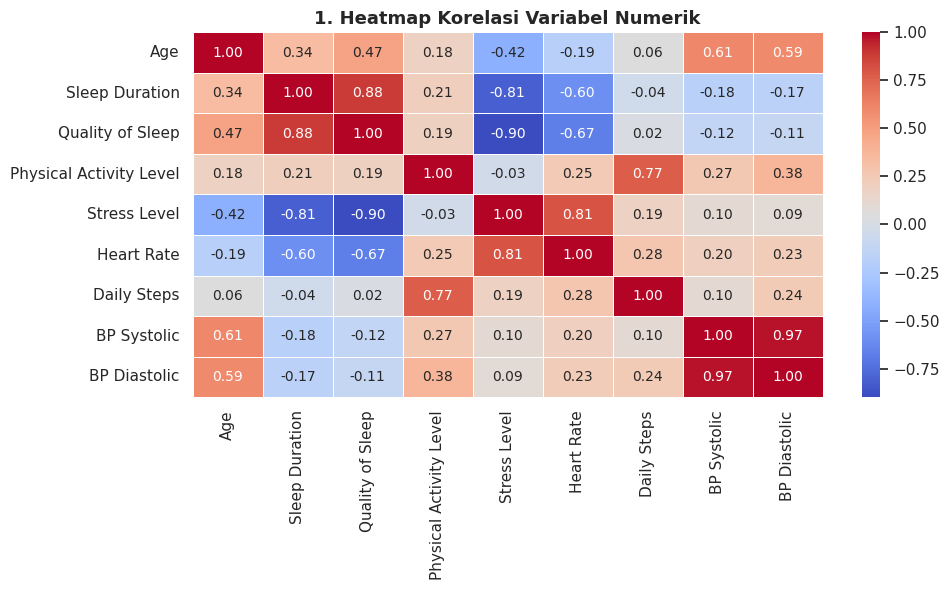

In [ ]:
#Heat Map
plt.figure(figsize=(10, 6))
numeric_cols = df_clean.select_dtypes(include=["number"]).columns.drop('Person ID', errors='ignore')
correlation_matrix = df_clean[numeric_cols].corr()

# Tampilkan heatmap tanpa Person ID
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("1. Heatmap Korelasi Variabel Numerik", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

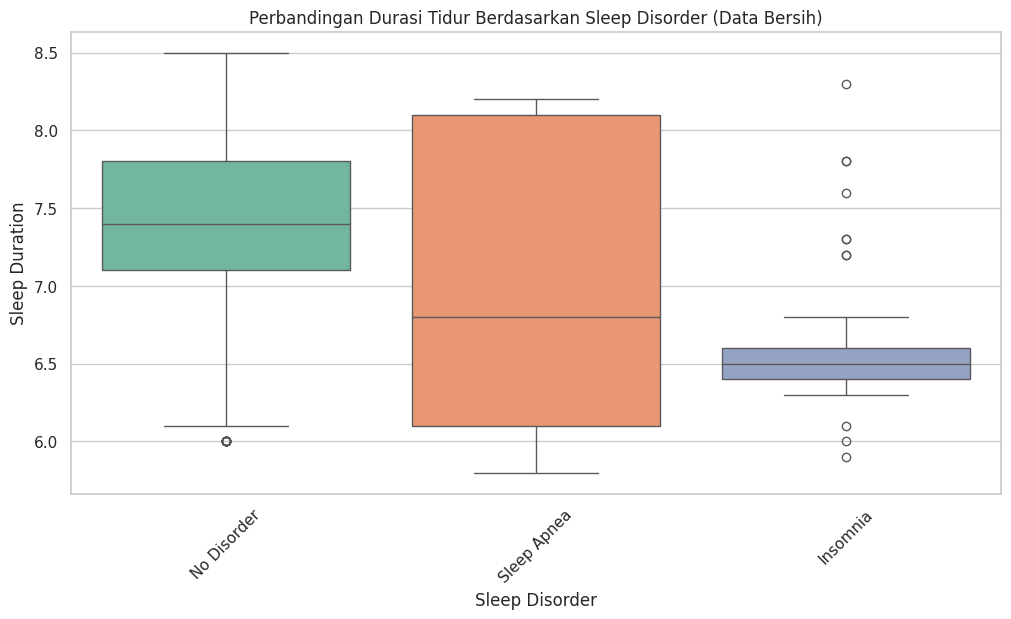

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sleep Disorder', y='Sleep Duration', data=df_clean, palette='Set2', hue='Sleep Disorder')
plt.xticks(rotation=45)
plt.title('Perbandingan Durasi Tidur Berdasarkan Sleep Disorder (Data Bersih)')
plt.show()

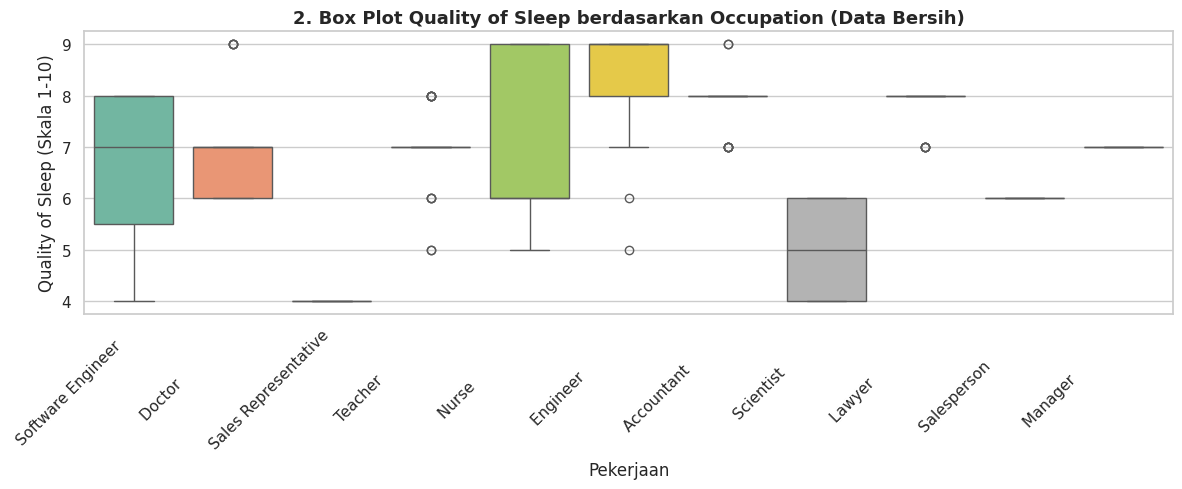

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x="Occupation", y="Quality of Sleep", hue="Occupation", palette="Set2")
plt.title("2. Box Plot Quality of Sleep berdasarkan Occupation (Data Bersih)", fontsize=13, fontweight="bold")
plt.xlabel("Pekerjaan")
plt.ylabel("Quality of Sleep (Skala 1-10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

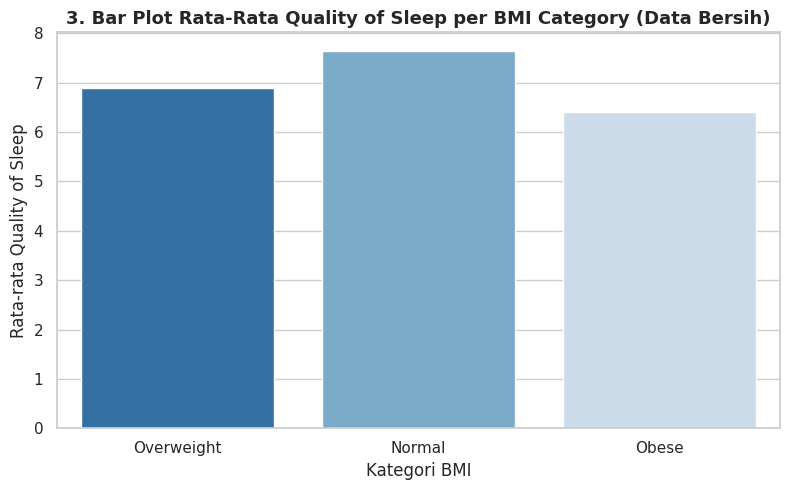

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x="BMI Category", y="Quality of Sleep", palette="Blues_r", errorbar=None)
plt.title("3. Bar Plot Rata-Rata Quality of Sleep per BMI Category (Data Bersih)", fontsize=13, fontweight="bold")
plt.xlabel("Kategori BMI")
plt.ylabel("Rata-rata Quality of Sleep")
plt.tight_layout()
plt.show()

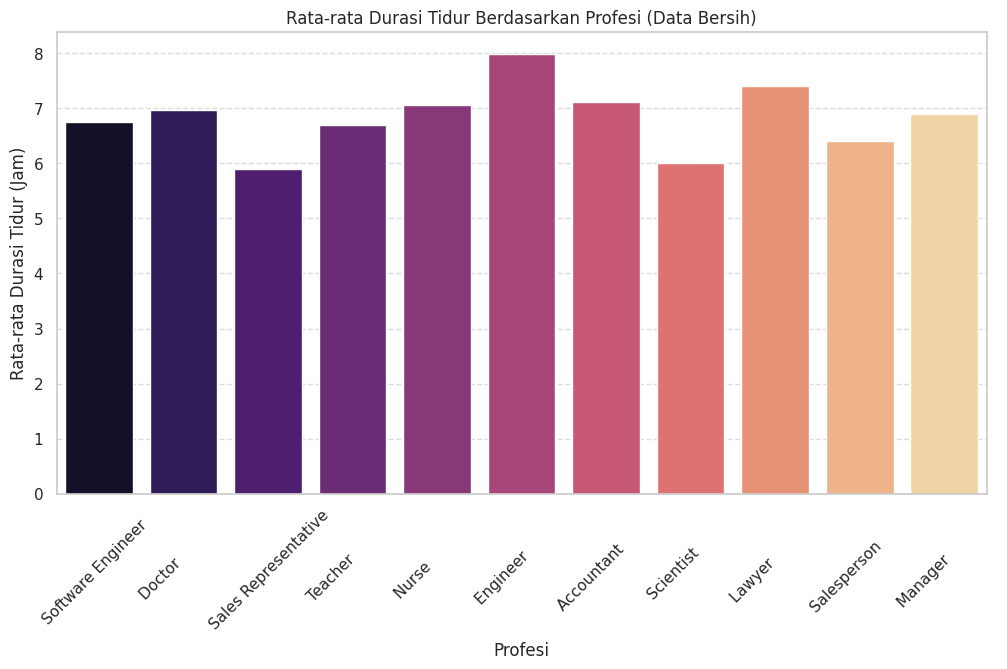

In [ ]:
# Visualisasi Bar Chart: Rata-rata Durasi Tidur per Profesi
plt.figure(figsize=(12, 6))

# x = kategori (Profesi)
# y = nilai yang mau dihitung (Durasi Tidur)
# Secara default sns.barplot bakal nampilin RATA-RATA (mean)
sns.barplot(x='Occupation', y='Sleep Duration', data=df_clean, palette='magma', ci=None)

plt.title('Rata-rata Durasi Tidur Berdasarkan Profesi (Data Bersih)')
plt.xlabel('Profesi')
plt.ylabel('Rata-rata Durasi Tidur (Jam)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Tambahin garis biar gampang bacanya
plt.show()

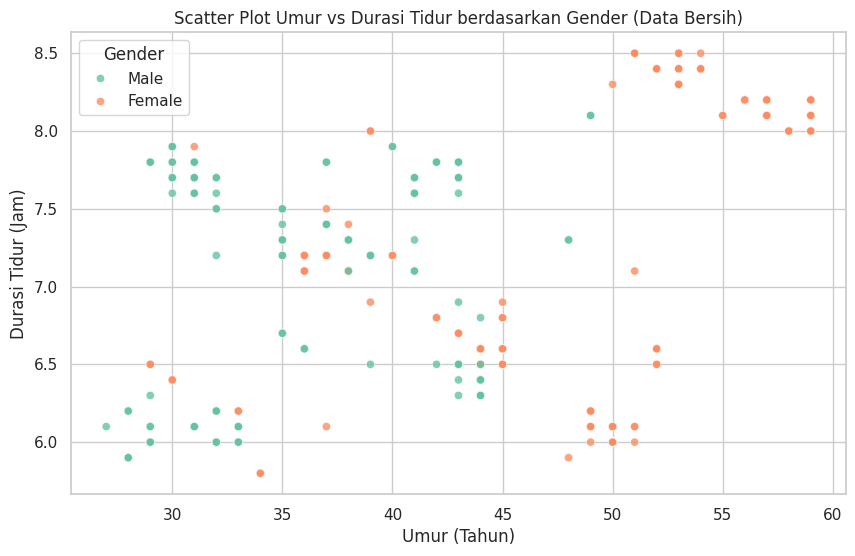

In [ ]:
# SCATTER PLOT
plt.figure(figsize=(10, 6))

# Kita langsung bersihkan spasi nama kolom & datanya di sini
df_mentah.columns = df_clean.columns.str.strip()

sns.scatterplot(
    data=df_clean,
    x='Age',
    y='Sleep Duration',
    hue=df_mentah['Gender'].str.strip(),  # Langsung di-strip di dalam sini
    palette='Set2',
    alpha=0.8
)

plt.title('Scatter Plot Umur vs Durasi Tidur berdasarkan Gender (Data Bersih)')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Durasi Tidur (Jam)')
plt.show()


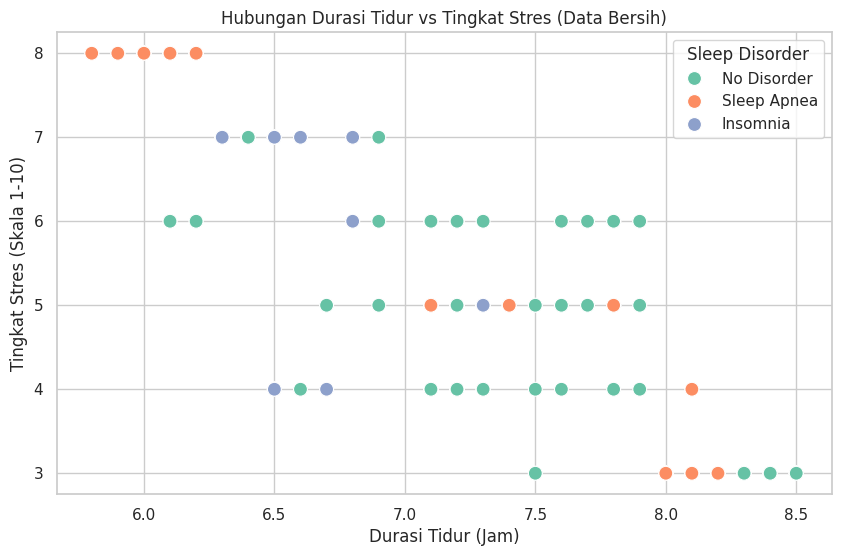

In [ ]:
# 1. Relasi antara durasi tidur dan tingkat stres, dengan warna berdasarkan Sleep Disorder
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['Sleep Duration'], y=df_mentah['Stress Level'], hue='Sleep Disorder', data=df_clean, palette='Set2', s=100,)
plt.title('Hubungan Durasi Tidur vs Tingkat Stres (Data Bersih)')
plt.xlabel('Durasi Tidur (Jam)')
plt.ylabel('Tingkat Stres (Skala 1-10)')
plt.show()

### Perbandingan Heart Rate outlier

### Visualisasi Outlier pada Heart Rate

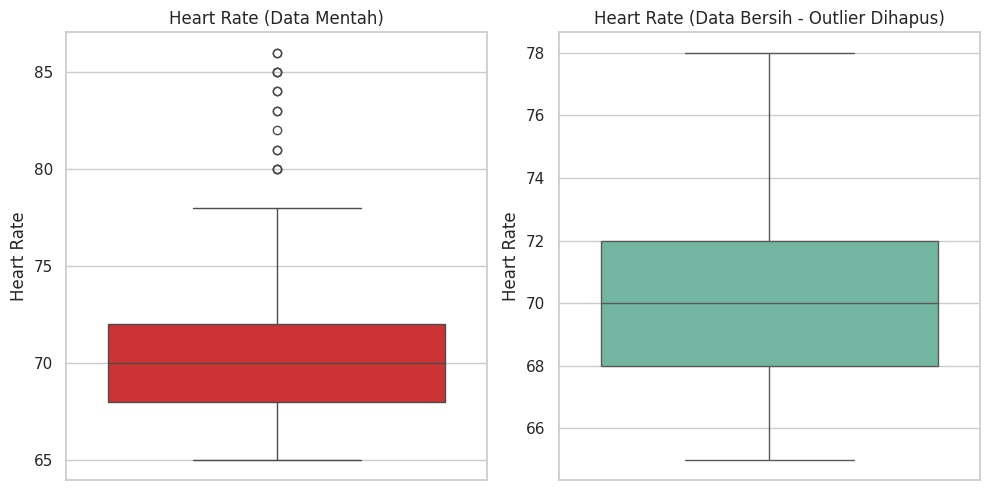

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Boxplot untuk Heart Rate sebelum pembersihan outlier
plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
sns.boxplot(y=df_mentah['Heart Rate'], palette='Set1')
plt.title('Heart Rate (Data Mentah)')
plt.ylabel('Heart Rate')

# Boxplot untuk Heart Rate setelah pembersihan outlier
plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
sns.boxplot(y=df_clean['Heart Rate'], palette='Set2')
plt.title('Heart Rate (Data Bersih - Outlier Dihapus)')
plt.ylabel('Heart Rate')

plt.tight_layout()
plt.show()

### Kesimpulan Secara keseluruhan temuan yang didapat mulai dari data mentah dan data bersih

### Data Mentah
Dari analisis data mentah, kami menemukan bahwa:
*   **Korelasi Antar Variabel**: `Quality of Sleep` menunjukkan korelasi positif yang kuat dengan `Sleep Duration` (0.88), dan korelasi negatif yang kuat dengan `Stress Level` (-0.90). Ini mengindikasikan bahwa semakin lama durasi tidur dan semakin rendah tingkat stres, kualitas tidur cenderung semakin baik. `BP Systolic` dan `BP Diastolic` memiliki korelasi yang sangat tinggi (0.97), yang wajar karena keduanya merupakan komponen tekanan darah.
*   **Durasi Tidur & Gangguan Tidur**: Individu tanpa gangguan tidur (`No Disorder`) cenderung memiliki durasi tidur yang lebih panjang dibandingkan dengan individu yang mengalami `Sleep Apnea` atau `Insomnia`. `Insomnia` memiliki durasi tidur terpendek.
*   **Kualitas Tidur & Pekerjaan**: Pekerjaan seperti `Engineer` dan `Nurse` cenderung memiliki `Quality of Sleep` yang lebih tinggi, sementara `Sales Representative` dan `Scientist` memiliki kualitas tidur yang lebih rendah.
*   **Kualitas Tidur & Kategori BMI**: Individu dengan kategori BMI `Normal` memiliki rata-rata kualitas tidur tertinggi dibandingkan `Overweight` dan `Obese`.
*   **Distribusi Usia dan Durasi Tidur**: Ada pola di mana kelompok usia tertentu memiliki durasi tidur yang lebih bervariasi, dan `Gender` juga berperan dalam distribusi ini.
*   **Tekanan Darah Sistolik & Gangguan Tidur**: Distribusi `BP Systolic` menunjukkan adanya perbedaan yang jelas antara kelompok gangguan tidur, dengan `Sleep Apnea` cenderung memiliki tekanan darah sistolik yang lebih tinggi.

### Data Bersih
Setelah proses pembersihan data (menghilangkan duplikat, mengisi missing value, dan menangani outlier pada `Heart Rate`), tidak ada perubahan signifikan pada pola-pola utama yang ditemukan pada data mentah. Ini menunjukkan bahwa proses pembersihan data berhasil menjaga integritas dan distribusi data yang asli. Beberapa poin penting yang tetap konsisten:
*   **Korelasi Tetap Kuat**: Korelasi antara `Sleep Duration`, `Quality of Sleep`, dan `Stress Level` tetap dominan dan konsisten.
*   **Pola Durasi Tidur dan Gangguan Tidur yang Sama**: Distribusi durasi tidur berdasarkan gangguan tidur tetap tidak berubah, menegaskan bahwa pola ini robust terhadap pembersihan outlier `Heart Rate`.
*   **Kualitas Tidur per Pekerjaan/BMI**: Tren `Quality of Sleep` berdasarkan `Occupation` dan `BMI Category` juga tetap sama, menunjukkan bahwa outlier tidak terlalu memengaruhi rata-rata dan median secara keseluruhan untuk kategori-kategori ini.

Secara umum, data bersih memberikan dasar yang lebih kuat untuk analisis dan modeling selanjutnya karena anomali data telah diatasi tanpa mengubah karakteristik esensial dari dataset.

---
## 👤 SECTION 3 — Preprocessing, Feature Engineering, Encode Target PCA
**Dikerjakan Oleh: _(Rifana Rachmadilla & Zaky Alfatih)_**

### Instruksi:
- Pastikan Section 2 sudah dijalankan karena (butuh variabel `df_bersih`).
- Simpan hasil akhir ke `X_train`, `X_test`, `y_train`, `y_test`

#### Target Encoding

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
#Menghubungkan dengan data bersih
df_preprocessing = df_clean.copy()

### 1. ENCODING KATEGORIKAL -> NUMERIK

In [ ]:
le = LabelEncoder()
#Encoding Kategorikal -> Numerik

kolom_kategorikal = ['Gender', 'Occupation', 'BMI Category', 'BP Category', 'Sleep Disorder']

for col in kolom_kategorikal:
    df_preprocessing[col] = le.fit_transform(df_preprocessing[col])

### 2. SCALING NUMERIK - STANDARISASI

In [ ]:
#Scaling numerik standarisasi
scaler = StandardScaler()

kolom_numerik = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                 'Stress Level', 'Heart Rate', 'Daily Steps', 'BP Systolic', 'BP Diastolic']

df_preprocessing[kolom_numerik] = scaler.fit_transform(df_preprocessing[kolom_numerik])

### 3. SPLIT DATA (FITUR X, TARGET Y)

In [ ]:
# Split data (fitur X, target y)
y = df_preprocessing['Sleep Disorder'] #kunci jawaban
X_sebelum_pca = df_preprocessing.drop(columns=['Person ID', 'Sleep Disorder']) # Drop ID gak berguna buat prediksi


### 4. REDUKSI DIMENSI MENGGUNAKAN METHODE PCA

In [ ]:
#PCA
pca = PCA(n_components=2)
X_setelah_pca = pca.fit_transform(X_sebelum_pca)

df_hasil_pca = pd.DataFrame(data=X_setelah_pca, columns=['Principal Component 1', 'Principal Component 2'])
#Menggabungkan Kolom target y
df_hasil_pca['Sleep Disorder (Target)'] = y.values

In [ ]:
print("=== HASIL AKHIR SECTION 3 (PREPROCESSING, ENCODING & PCA) ===")
print(f"Ukuran data awal sebelum PCA: {X_sebelum_pca.shape}")
print(f"Ukuran data akhir setelah PCA: {X_setelah_pca.shape}")
print(f"Persentase informasi yang berhasil dijaga (Variance Ratio): {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")
print("-" * 60)
print("Preview 5 data teratas :")


print ("=== MAPPING LABEL ENCODING ===")
print("Kelas yang ada dalam data:")
print(le.classes_)
print("Mapping label encoding:")
print(dict(zip(le.transform(le.classes_), le.classes_)))

print("==========" * 9)

df_hasil_pca.head()

=== HASIL AKHIR SECTION 3 (PREPROCESSING, ENCODING & PCA) ===
Ukuran data awal sebelum PCA: (374, 13)
Ukuran data akhir setelah PCA: (374, 2)
Persentase informasi yang berhasil dijaga (Variance Ratio): 72.08%
------------------------------------------------------------
Preview 5 data teratas :
=== MAPPING LABEL ENCODING ===
Kelas yang ada dalam data:
['Insomnia' 'No Disorder' 'Sleep Apnea']
Mapping label encoding:
{np.int64(0): 'Insomnia', np.int64(1): 'No Disorder', np.int64(2): 'Sleep Apnea'}


,Principal Component 1,Principal Component 2,Sleep Disorder (Target)
0,5.149489,2.428634,1
1,-2.827600,3.536694,1
2,-2.827600,3.536694,1
3,2.964082,2.989065,2
4,2.964082,2.989065,2


### Visual hasil dari PCA

### Tabel Hasil Reduksi Dimensi PCA

In [ ]:
display(df_hasil_pca)

,Principal Component 1,Principal Component 2,Sleep Disorder (Target)
0,5.149489,2.428634,1
1,-2.827600,3.536694,1
2,-2.827600,3.536694,1
3,2.964082,2.989065,2
4,2.964082,2.989065,2
5,5.704834,2.721447,0
6,6.367712,1.280433,0
7,-3.337891,0.897712,1
8,-3.337891,0.897712,1
9,-3.337891,0.897712,1


---
## 👤 SECTION 4 — Modeling & Evaluasi
**Dikerjakan Oleh: _(Shaquilla Azizah & Fadli Ghafatul Hijriah)_**

### Instruksi:
- Pastikan Section 3 sudah dijalankan karena (butuh `X_train`, `X_test`, `y_train`, `y_test`).
- Membuat 3 jenis model: Regression, Classification, Clustering.
- Tulis kesimpulan model terbaik di akhir section.

### 4.1 Logistic Regression — Prediksi Sleep Disorder tanpa PCA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Gunakan data hasil preprocessing dari Section 3
# X = df_preprocessing.drop(columns=["Person ID", "Sleep Disorder"])
# y = df_preprocessing["Sleep Disorder"]

X_train, X_test, y_train, y_test = train_test_split(
    X_sebelum_pca, y, test_size=0.2, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
acc_nopca = accuracy_score(y_test, y_pred)
f1_nopca = f1_score(y_test, y_pred, average='weighted')

print("=== Hasil Logistic Regression tanpa PCA ===")
print(f"Akurasi: {acc_nopca:.4f}")
print(f"F1 Score (weighted): {f1_nopca:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Hasil Logistic Regression tanpa PCA ===
Akurasi: 0.9333
F1 Score (weighted): 0.9337

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       1.00      0.98      0.99        44
           2       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.90      0.90      0.90        75
weighted avg       0.94      0.93      0.93        75


Confusion Matrix:
[[12  0  3]
 [ 1 43  0]
 [ 1  0 15]]


### 4.2 Logistic Regresion — Prediksi Sleep Disorder dengan PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Gunakan data hasil preprocessing dari Section 3
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_setelah_pca, y, test_size=0.2, random_state=42, stratify=y
)

logreg_pca = LogisticRegression(max_iter=1000, random_state=42)
logreg_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = logreg_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)
f1_pca = f1_score(y_test_pca, y_pred_pca, average='weighted')

print("=== Hasil Logistic Regression dengan PCA 2 komponen ===")
print(f"Akurasi: {acc_pca:.4f}")
print(f"F1 Score (weighted): {f1_pca:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_pca, y_pred_pca))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nVariance Ratio yang dijaga:", pca.explained_variance_ratio_)
print("Total variance preserved:", pca.explained_variance_ratio_.sum())

=== Hasil Logistic Regression dengan PCA 2 komponen ===
Akurasi: 0.6933
F1 Score (weighted): 0.6152

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.80      0.63        15
           1       0.77      0.91      0.83        44
           2       0.00      0.00      0.00        16

    accuracy                           0.69        75
   macro avg       0.43      0.57      0.49        75
weighted avg       0.56      0.69      0.62        75


Confusion Matrix:
[[12  3  0]
 [ 4 40  0]
 [ 7  9  0]]

Variance Ratio yang dijaga: [0.54240688 0.17839017]
Total variance preserved: 0.7207970537901833


### 4.3 Visual hasil perbandingan model logistic regresion tanpa PCA vs dengan PCA

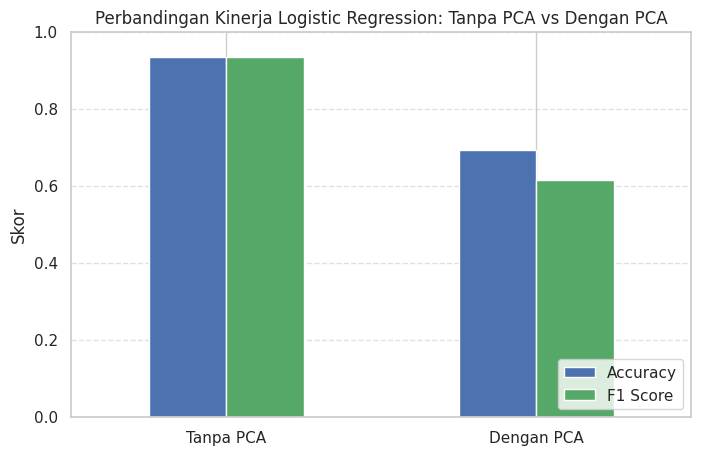

In [ ]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Tanpa PCA': [acc_nopca, f1_nopca],
    'Dengan PCA': [acc_pca, f1_pca]
}, index=['Accuracy', 'F1 Score']).T

comparison.plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#55A868'])
plt.title('Perbandingan Kinerja Logistic Regression: Tanpa PCA vs Dengan PCA')
plt.ylabel('Skor')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower right')
plt.show()

### 4.4 Visual hasil confusion matriks model tanpa PCA dan dengan PCA

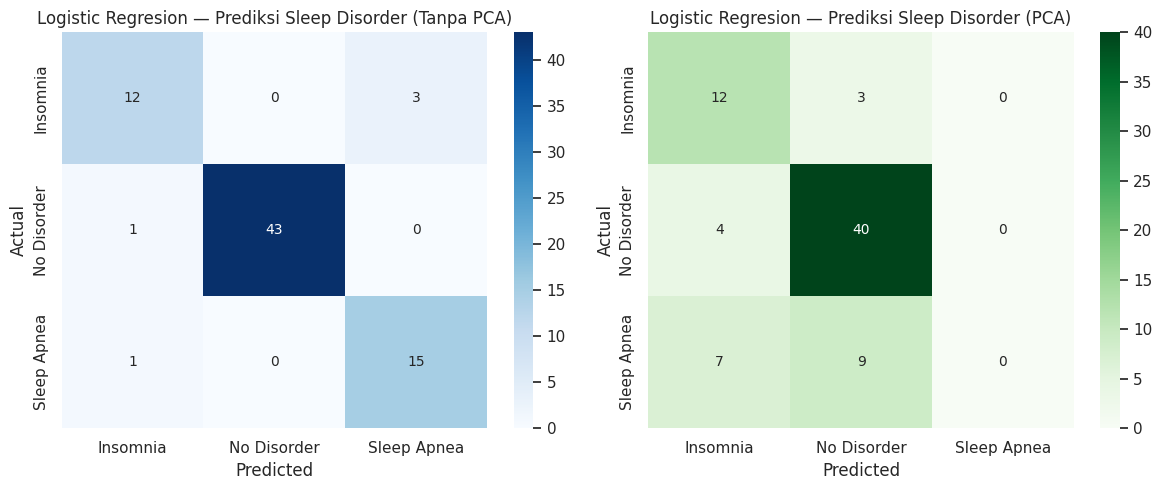

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ambil true/pred untuk kedua model (fallback jika belum tersedia)
try:
    y_true_n = y_test
    y_pred_n = y_pred
except NameError:
    y_true_n = y_test
    y_pred_n = logreg.predict(X_test)

try:
    y_true_p = y_test_pca
    y_pred_p = y_pred_pca
except NameError:
    y_true_p = y_test_pca
    y_pred_p = logreg_pca.predict(X_test_pca)

# Hitung confusion matrix
cm_n = confusion_matrix(y_true_n, y_pred_n)
cm_p = confusion_matrix(y_true_p, y_pred_p)

# Labels kelas (gunakan target_encoder.classes_ untuk nama kategori)
labels = le.classes_

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_n, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Logistic Regresion — Prediksi Sleep Disorder (Tanpa PCA)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Logistic Regresion — Prediksi Sleep Disorder (PCA)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 4.5 Random Forest prediksi Sleep Disorder Tanpa PCA


AKURASI MODEL RANDOM FOREST (TANPA PCA): 96.00%

📋 CLASSIFICATION REPORT (TANPA PCA):
              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
 No Disorder       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



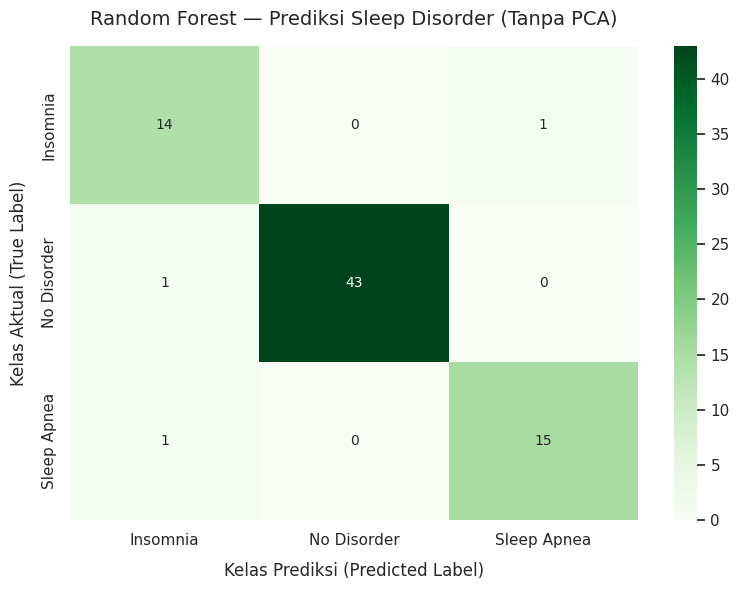

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Split Data menjadi Training dan Testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_sebelum_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Inisialisasi Model Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 5. Training Model menggunakan data asli (Tanpa PCA)
rf_model.fit(X_train, y_train)

# 6. Prediksi Menggunakan Data Testing
y_pred = rf_model.predict(X_test)

# 7. Evaluasi Akurasi
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*40)
print(f"AKURASI MODEL RANDOM FOREST (TANPA PCA): {accuracy * 100:.2f}%")
print("="*40)

# 8. Tampilkan Classification Report
print("\n📋 CLASSIFICATION REPORT (TANPA PCA):")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# ========================================================
# 📊 VISUALISASI CONFUSION MATRIX (TANPA PCA)
# ========================================================

# Hitung matriks dari hasil prediksi tanpa PCA
cm = confusion_matrix(y_test, y_pred)
class_names = le.classes_

# Gambar grafik heatmap menggunakan warna 'Greens'
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',  # Warna hijau untuk membedakan dengan versi PCA yang biru
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Random Forest — Prediksi Sleep Disorder (Tanpa PCA)', fontsize=14, pad=15)
plt.xlabel('Kelas Prediksi (Predicted Label)', fontsize=12, labelpad=10)
plt.ylabel('Kelas Aktual (True Label)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### 4.5 Visualisasi satu buah Node dari Model tanpa PCA

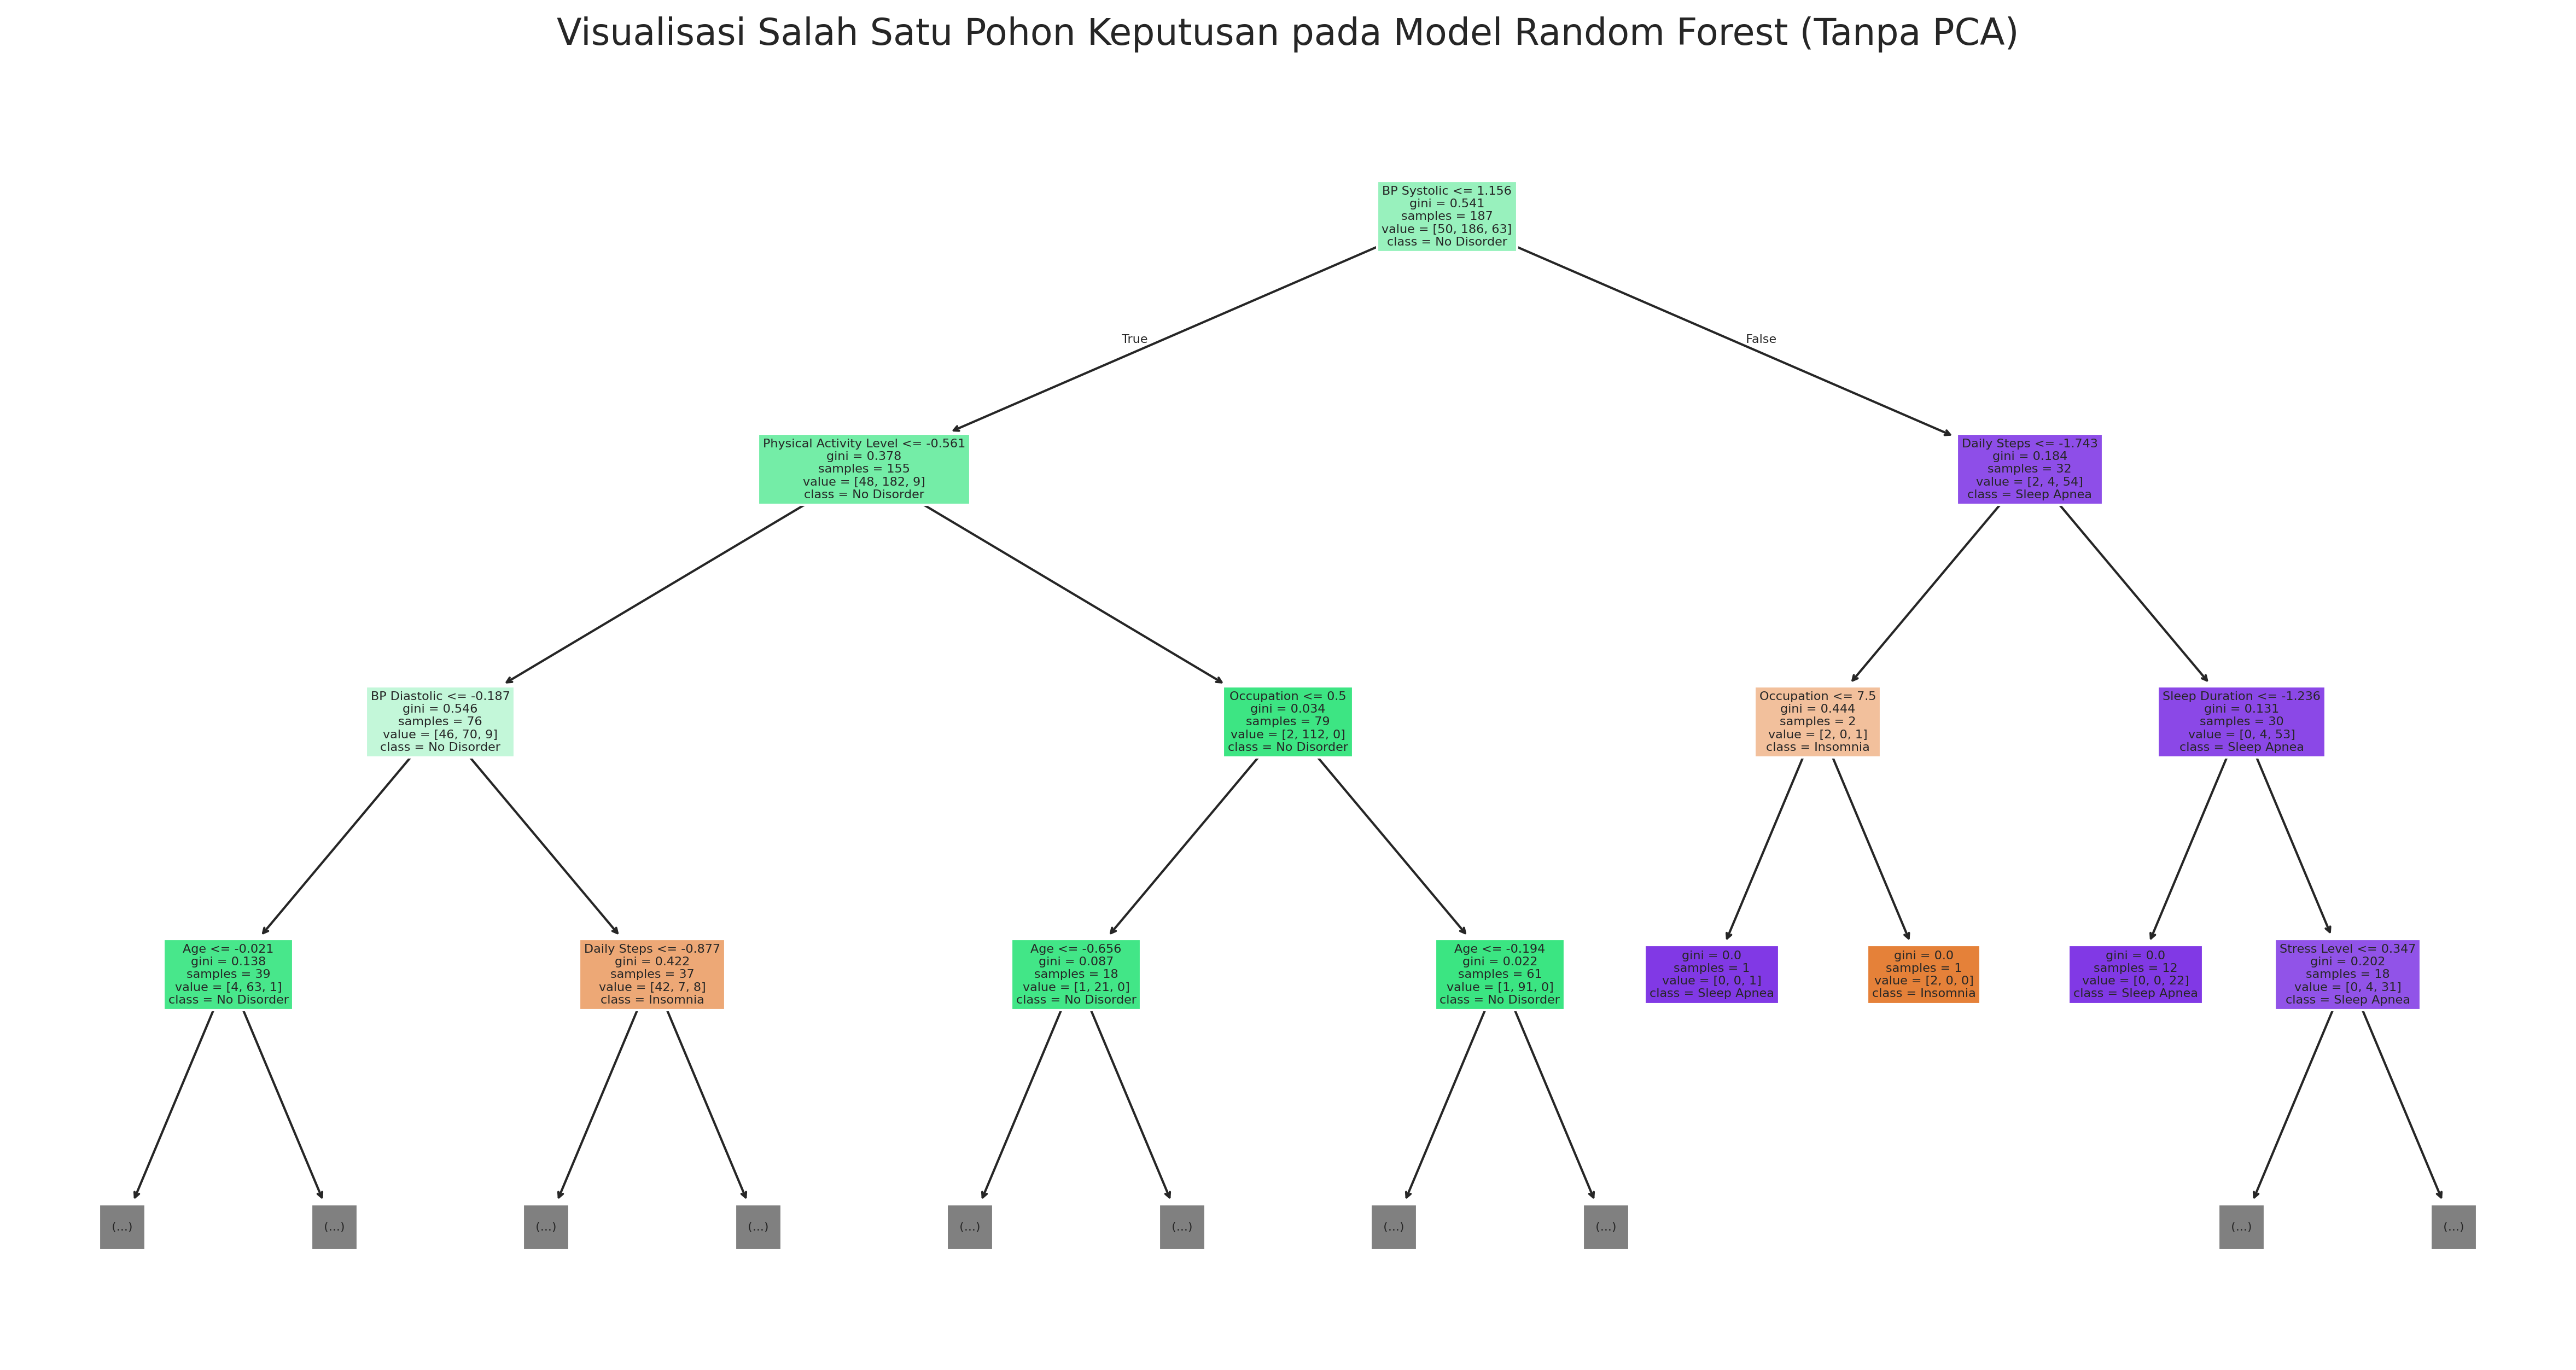

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# 1. Definisikan kembali data agar sel mandiri
X = df_preprocessing.drop(columns=["Person ID", "Sleep Disorder"])
y = df_preprocessing["Sleep Disorder"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Latih kembali model Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 3. Ambil salah satu pohon (pohon pertama/indeks 0)
pohon_pertama = rf.estimators_[0]

# 4. Gambar grafik pohon keputusan
plt.figure(figsize=(20, 10), dpi=300) # dpi=300 agar gambar tajam dan teks terbaca
plot_tree(pohon_pertama,
          feature_names=X.columns,
          class_names=['Insomnia', 'No Disorder', 'Sleep Apnea'],
          filled=True,
          max_depth=3) # Dibatasi kedalaman 3 agar kotak tidak terlalu menumpuk
plt.title("Visualisasi Salah Satu Pohon Keputusan pada Model Random Forest (Tanpa PCA)", fontsize=16, pad=20)
plt.show()


### 4.6 Random Forest prediksi Sleep Disorder Dengan PCA

=== Hasil Random Forest dengan PCA 2 komponen ===
== AKURASI MODEL RANDOM FOREST + PCA: 90.67% ==

📋 CLASSIFICATION REPORT (WITH PCA):
              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
 No Disorder       0.95      0.93      0.94        44
 Sleep Apnea       0.81      0.81      0.81        16

    accuracy                           0.91        75
   macro avg       0.88      0.89      0.89        75
weighted avg       0.91      0.91      0.91        75



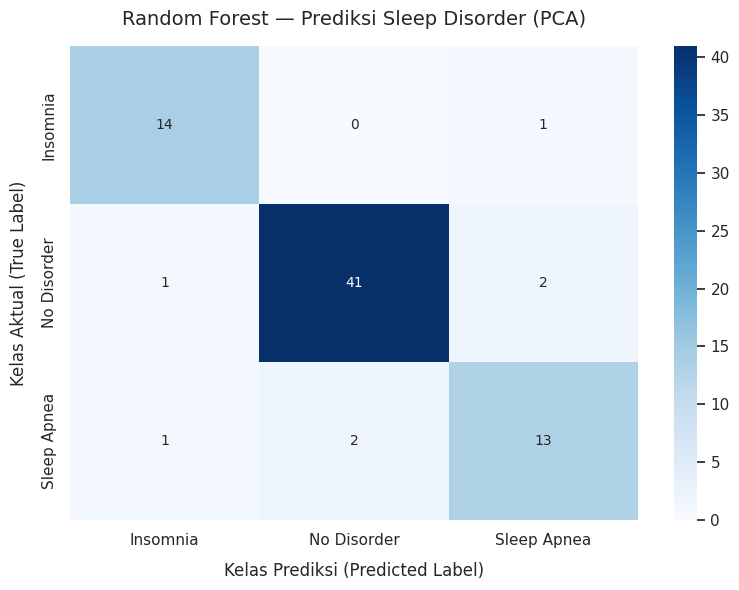

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MODELING RANDOM FOREST (MENGGUNAKAN DATA PCA DARI SECTION 3)

# 1. Inisialisasi Model Random Forest Classifier
rf_model_pca = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Training Model menggunakan data variabel hasil PCA dari Section 3
# (Jika temanmu menggunakan nama variabel yang berbeda, sesuaikan nama X_train_pca & y_train di bawah)
rf_model_pca.fit(X_train_pca, y_train)

# 3. Prediksi Menggunakan Data Testing hasil PCA dari Section 3
y_pred_pca = rf_model_pca.predict(X_test_pca)

# EVALUASI MODEL & VISUALISASI

# 4. Hitung Akurasi
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("=== Hasil Random Forest dengan PCA 2 komponen ===")
print(f"== AKURASI MODEL RANDOM FOREST + PCA: {accuracy_pca * 100:.2f}% ==")

# 5. Tampilkan Classification Report
# Catatan: target_encoder di bawah berasumsi variabel target_encoder sudah di-fit di Section 3
print("\n📋 CLASSIFICATION REPORT (WITH PCA):")
print(classification_report(y_test, y_pred_pca, target_names=le.classes_))

# 6. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pca)
class_names = le.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Random Forest — Prediksi Sleep Disorder (PCA)', fontsize=14, pad=15)
plt.xlabel('Kelas Prediksi (Predicted Label)', fontsize=12, labelpad=10)
plt.ylabel('Kelas Aktual (True Label)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

### 4.6 Visualisasi satu buah Node dari Model dengan PCA

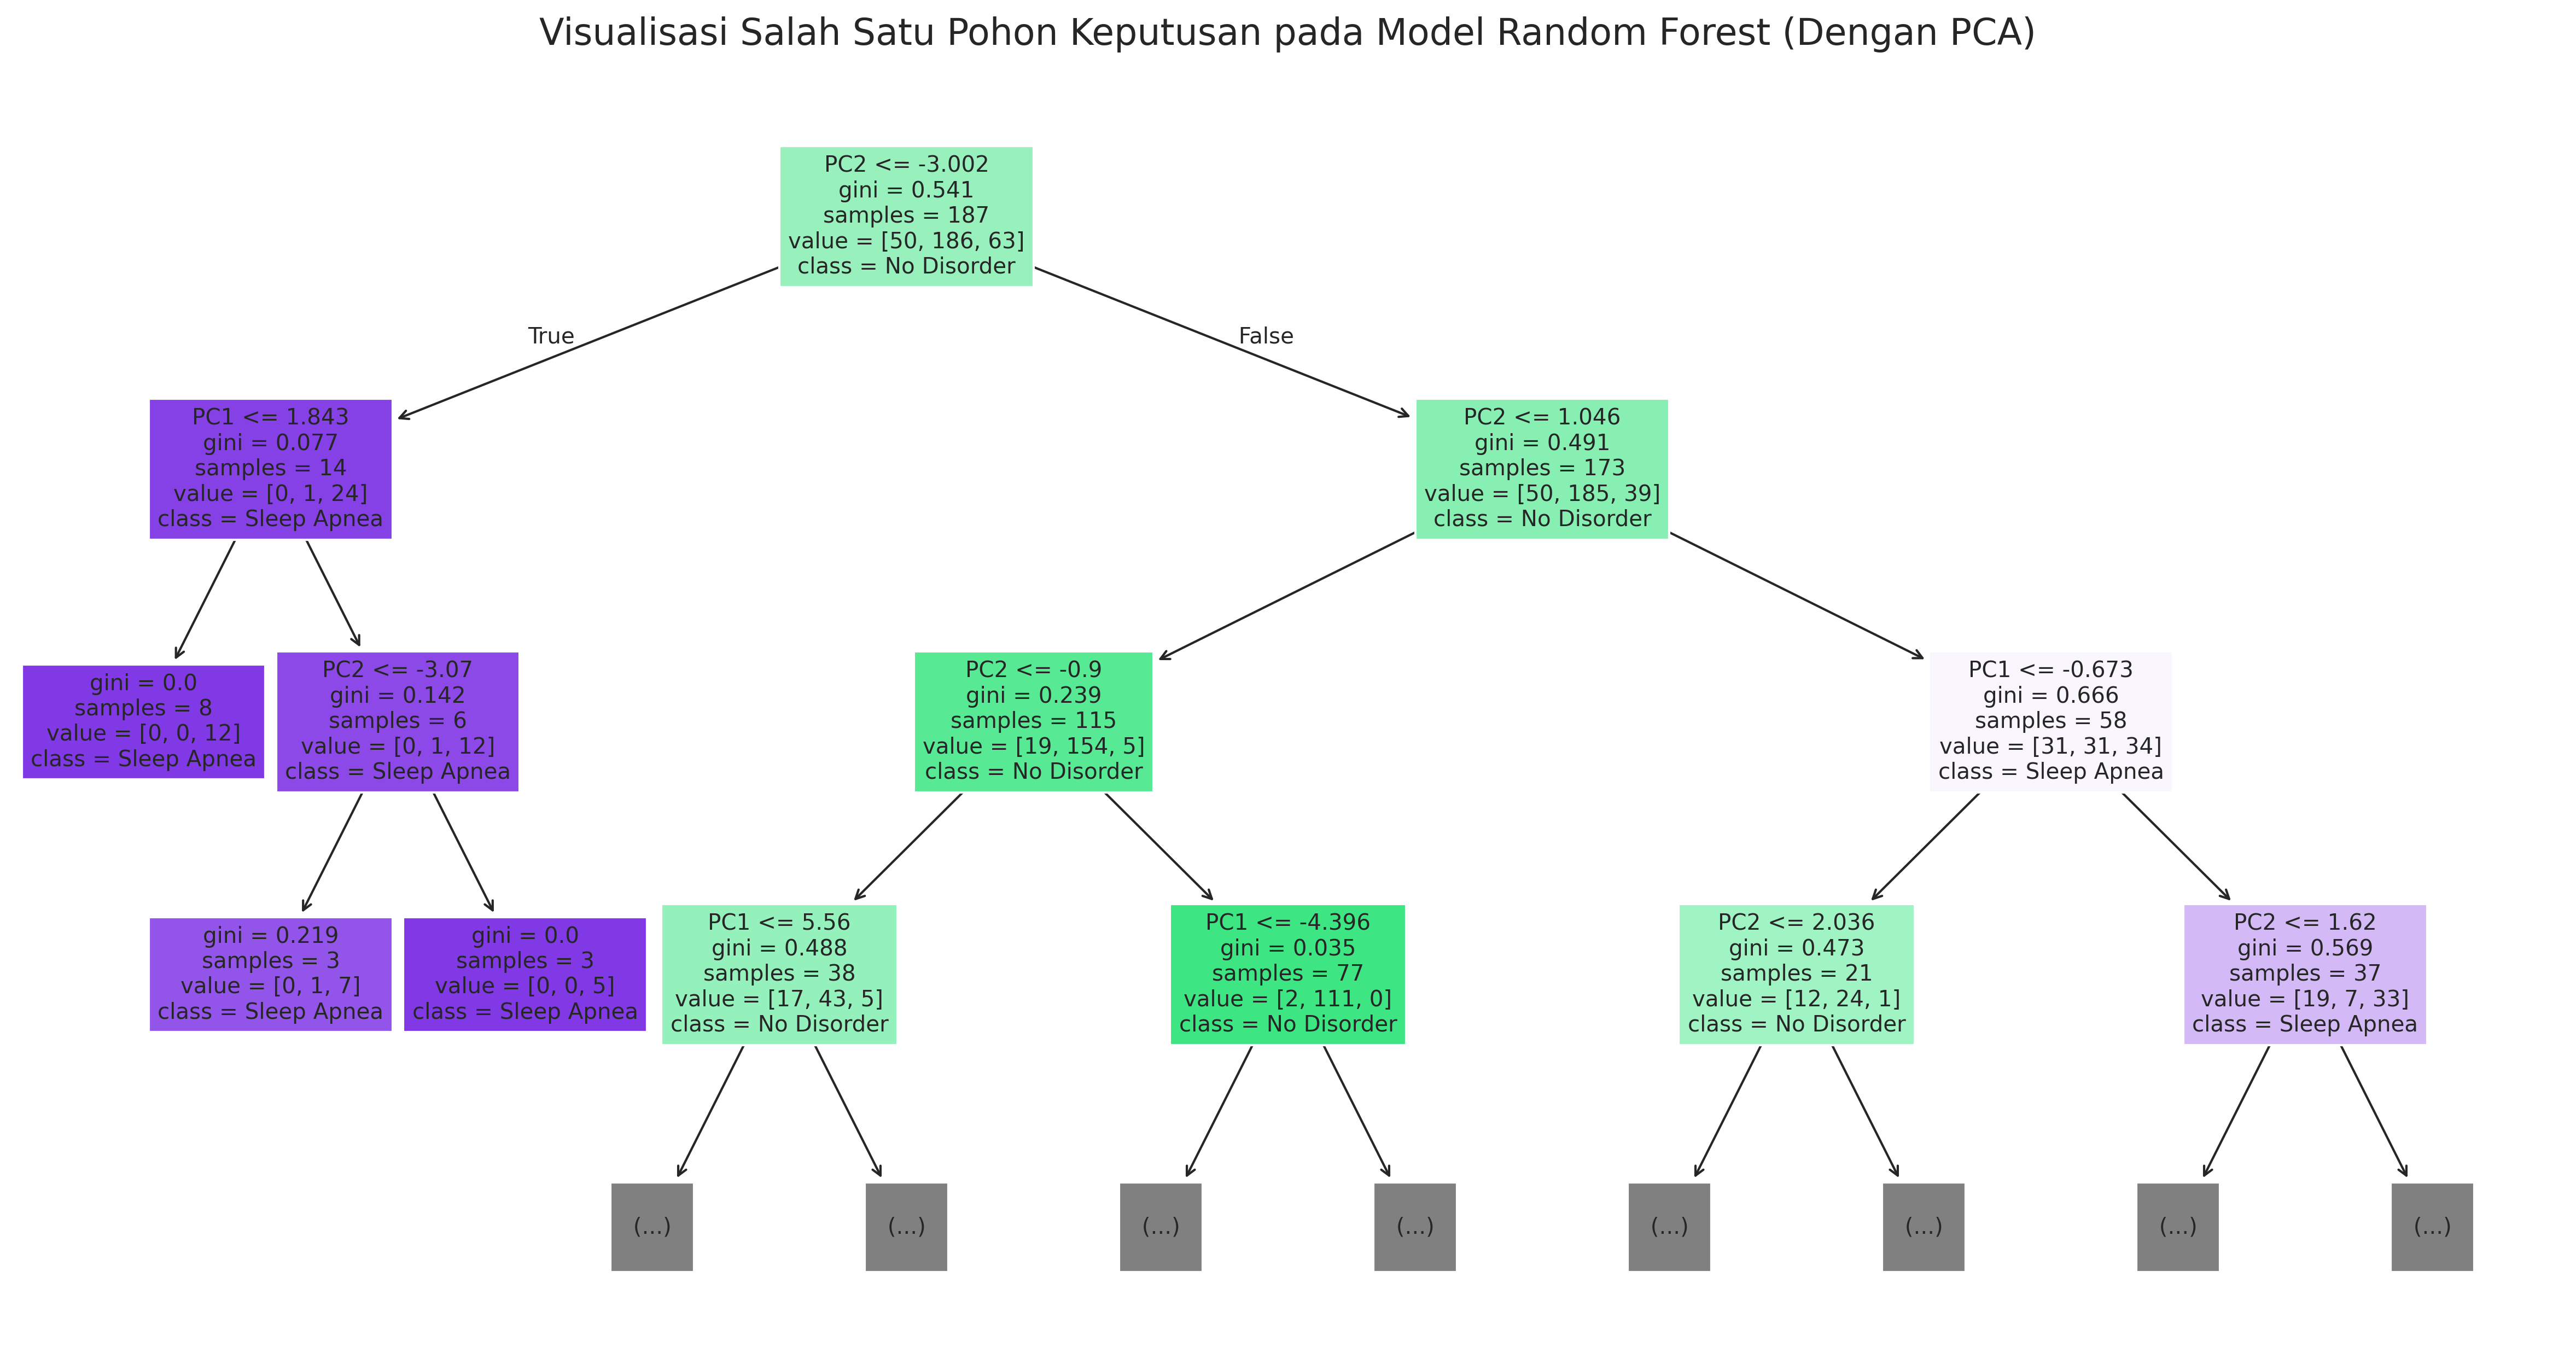

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree
import pandas as pd

# 1. TRAINING MODEL MENGGUNAKAN DATA PCA DARI SECTION 3

# (Pastikan nama variabel X_train_pca, X_test_pca, y_train, y_test sudah sesuai dengan Section 3)
rf_model_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_pca.fit(X_train_pca, y_train)

# Prediksi untuk evaluasi
y_pred_pca = rf_model_pca.predict(X_test_pca)

# 3. VISUALISASI POHON KEPUTUSAN (TREE VISUALIZATION)

# Ambil salah satu pohon dari forest (indeks 0)
pohon_pertama_pca = rf_model_pca.estimators_[0]

# Karena pakai PCA, nama fiturnya berubah menjadi Principal Components
# Jumlah nama di bawah ini harus sama dengan jumlah n_components yang dibuat di Section 3 (misal: 5)
nama_komponen_pca = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

plt.figure(figsize=(20, 10), dpi=300) # dpi=300 agar gambar sangat tajam saat di-zoom
plot_tree(pohon_pertama_pca,
          feature_names=nama_komponen_pca,              # Menggunakan nama PC1, PC2, dst.
          class_names=le.classes_,           # Mengambil nama kelas otomatis ('Insomnia', 'No Disorder', 'Sleep Apnea')
          filled=True,
          max_depth=3)                                   # Dibatasi ke dalaman 3 agar tidak berantakan
plt.title("Visualisasi Salah Satu Pohon Keputusan pada Model Random Forest (Dengan PCA)", fontsize=16, pad=20)
plt.show()


### 4.7 Feature paling berpengaruh pada model

In [ ]:
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_sebelum_pca.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n📊 FITUR PALING BERPENGARUH (FEATURE IMPORTANCE):")
print(feature_imp_df.to_string(index=False))


📊 FITUR PALING BERPENGARUH (FEATURE IMPORTANCE):
                Feature  Importance
           BMI Category    0.168385
            BP Systolic    0.150045
             Occupation    0.134607
           BP Diastolic    0.111682
         Sleep Duration    0.110229
                    Age    0.105805
Physical Activity Level    0.062182
            Daily Steps    0.047723
             Heart Rate    0.032352
           Stress Level    0.029781
       Quality of Sleep    0.024743
            BP Category    0.013803
                 Gender    0.008664


In [ ]:
display(feature_imp_df)

,Feature,Importance
7,BMI Category,0.168385
11,BP Systolic,0.150045
2,Occupation,0.134607
12,BP Diastolic,0.111682
3,Sleep Duration,0.110229
1,Age,0.105805
5,Physical Activity Level,0.062182
10,Daily Steps,0.047723
9,Heart Rate,0.032352
6,Stress Level,0.029781


### ✍️ Kesimpulan Model dan Evaluasi

Berdasarkan eksperimen modeling yang telah dilakukan dengan menggunakan Logistic Regression dan Random Forest, baik dengan maupun tanpa Principal Component Analysis (PCA), berikut adalah ringkasan performa dan penjelasan hasil:

#### 1. Performa Model:

*   **Logistic Regression Tanpa PCA**
    *   **Akurasi:** 0.9333 (93.33%)
    *   **F1 Score (weighted):** 0.9337
    *   **Komentar:** Memberikan hasil yang cukup baik dalam memprediksi gangguan tidur.

*   **Logistic Regression Dengan PCA (2 Komponen)**
    *   **Akurasi:** 0.6933 (69.33%)
    *   **F1 Score (weighted):** 0.6152
    *   **Komentar:** Terjadi penurunan akurasi yang signifikan dibandingkan tanpa PCA.

*   **Random Forest Tanpa PCA**
    *   **Akurasi:** 0.9600 (96.00%)
    *   **F1 Score (weighted):** 0.9600
    *   **Komentar:** Model terbaik yang dihasilkan, menunjukkan performa yang sangat tinggi.

*   **Random Forest Dengan PCA (2 Komponen)**
    *   **Akurasi:** 0.9067 (90.67%)
    *   **F1 Score (weighted):** 0.9067
    *   **Komentar:** Akurasi sedikit menurun dibandingkan tanpa PCA, namun masih lebih baik dari Logistic Regression dengan PCA.

#### 2. Model Terbaik

Model **Random Forest Tanpa PCA** adalah model terbaik dengan akurasi 96.00%. Model ini mampu mengklasifikasikan 'Sleep Disorder' dengan sangat baik tanpa perlu reduksi dimensi.

#### 3. Mengapa Akurasi Menurun dengan PCA?

Penurunan akurasi, terutama pada Logistic Regression, setelah penerapan PCA (dengan 2 komponen yang menjaga 72.08% varians) dapat dijelaskan oleh beberapa faktor:

*   **Kehilangan Informasi Diskriminatif:** PCA berfokus pada mempertahankan varians terbesar dalam data. Namun, tidak semua varians adalah informasi yang relevan untuk tujuan klasifikasi. Ada kemungkinan bahwa 27.92% varians yang hilang atau tidak dipertahankan oleh 2 komponen utama PCA mengandung informasi krusial yang membantu model membedakan kelas-kelas 'Sleep Disorder'. Untuk model klasifikasi, fitur yang penting mungkin bukan fitur yang memiliki varians terbesar.
*   **Asumsi Linearitas PCA:** PCA adalah teknik linier. Jika hubungan antara fitur asli dan label target (`Sleep Disorder`) bersifat non-linier, maka transformasi linier oleh PCA mungkin tidak efektif dalam menangkap pola-pola non-linier tersebut. Data asli mungkin memiliki struktur non-linier yang sensitif terhadap reduksi dimensi linier.
*   **Komponen Tidak Optimal untuk Klasifikasi:** Meskipun PCA mengurangi dimensi, komponen-komponen utama yang dihasilkan mungkin tidak selalu optimal untuk tugas klasifikasi. Fitur asli mungkin memiliki fitur 'Noise' atau 'Redundant' yang sebenarnya tidak terlalu memengaruhi kinerja model. Dengan 2 komponen PCA, mungkin terlalu banyak informasi yang 'dibuang' sehingga merugikan model.

#### 4. Mengapa Random Forest Lebih Baik dari Logistic Regression?

Random Forest menunjukkan kinerja yang secara signifikan lebih baik daripada Logistic Regression, baik dengan maupun tanpa PCA, karena karakteristik fundamentalnya:

*   **Penanganan Non-Linearitas:** Random Forest adalah model berbasis pohon keputusan yang sangat baik dalam menangani hubungan non-linier dan interaksi kompleks antar fitur. Tidak seperti Logistic Regression yang merupakan model linier (berasumsi hubungan linier antara fitur dan probabilitas kelas), Random Forest dapat menyesuaikan diri dengan pola data yang lebih rumit.
*   **Ensemble Learning dan Reduksi Overfitting:** Random Forest adalah metode _ensemble_ yang membangun banyak pohon keputusan secara independen dan menggabungkan hasilnya (melalui _voting_). Ini secara efektif mengurangi masalah _overfitting_ yang sering terjadi pada satu pohon keputusan dan meningkatkan generalisasi model pada data yang belum pernah dilihat. Logistic Regression tidak memiliki mekanisme bawaan seperti ini.
*   **Toleransi Terhadap Outlier dan Noise:** Model berbasis pohon, termasuk Random Forest, cenderung lebih tangguh terhadap _outlier_ dan _noise_ dalam data dibandingkan model linier seperti Logistic Regression, yang sensitif terhadap nilai-nilai ekstrem.
*   **Pentingnya Interaksi Fitur:** Random Forest secara implisit dapat menangkap interaksi antara fitur-fitur yang berbeda tanpa perlu rekayasa fitur manual. Interaksi kompleks antara berbagai faktor kesehatan dan gaya hidup mungkin sangat berpengaruh terhadap gangguan tidur, dan Random Forest mampu mengeksplorasi interaksi ini dengan lebih baik.

Dengan demikian, Random Forest lebih adaptif dan kuat dalam menangani kompleksitas data yang ada dalam dataset 'Sleep Health and Lifestyle', yang pada akhirnya menghasilkan akurasi klasifikasi yang lebih tinggi.

---
## 👤 SECTION 5 — Kesimpulan Akhir
**Dikerjakan Oleh: _(Fadli Ghafatul Hijriah)_**

### Instruksi:
- Kumpulkan insight dari Section 1-4.
- Susun jadi narasi utuh di bawah untuk dijadikan slide presentasi.

### Ringkasan Proses
Proyek ini diawali dengan analisis dataset _Sleep Health and Lifestyle_ yang berisi informasi kesehatan dan gaya hidup 374 individu. Tahap pembersihan data meliputi penanganan _missing values_ (kolom `Sleep Disorder` diisi dengan 'No Disorder'), penghapusan duplikat, pemisahan kolom `Blood Pressure` menjadi `BP Systolic` dan `BP Diastolic` diikuti dengan kategorisasi menjadi `BP Category`, serta penanganan _outlier_ pada `Heart Rate` dengan imputasi rata-rata. Selanjutnya, tahap _preprocessing_ melibatkan _encoding_ variabel kategorikal menggunakan `LabelEncoder` dan _scaling_ fitur numerik dengan `StandardScaler`. Untuk reduksi dimensi, Principal Component Analysis (PCA) diterapkan, menghasilkan 2 komponen yang menjaga 72.08% varians. Model yang diuji adalah Logistic Regression dan Random Forest, masing-masing dengan dan tanpa PCA.

### Insight Utama
*   **Korelasi dan Kualitas Tidur**: Terdapat korelasi negatif yang kuat antara `Quality of Sleep` dengan `Stress Level`, dan positif dengan `Sleep Duration`. Ini mengindikasikan bahwa semakin rendah tingkat stres dan semakin lama durasi tidur, semakin baik kualitas tidur seseorang. Individu tanpa gangguan tidur cenderung memiliki durasi tidur lebih panjang, sedangkan penderita Insomnia memiliki durasi tidur terpendek.
*   **Faktor Demografi dan Kesehatan**: Profesi seperti Engineer dan Nurse cenderung memiliki kualitas tidur lebih tinggi, sementara Sales Representative dan Scientist cenderung lebih rendah. Individu dengan BMI `Normal` memiliki kualitas tidur terbaik. Terdapat pola distribusi `BP Systolic` yang berbeda signifikan antar kategori gangguan tidur, di mana penderita `Sleep Apnea` cenderung memiliki tekanan darah sistolik yang lebih tinggi.
*   **Performa Model**: Model **Random Forest tanpa PCA** menunjukkan kinerja terbaik dengan akurasi 96.00% dan F1 Score (weighted) 0.9600. Model ini mampu mengklasifikasikan gangguan tidur dengan sangat akurat.
*   **Efek PCA**: Penerapan PCA menurunkan akurasi kedua model, terutama Logistic Regression (dari 93.33% menjadi 69.33%). Hal ini menunjukkan bahwa informasi diskriminatif yang penting untuk klasifikasi mungkin hilang dalam proses reduksi dimensi linier PCA, dan bahwa fitur asli memiliki nilai informatif yang lebih tinggi untuk model ini.
*   **Keunggulan Random Forest**: Random Forest lebih unggul dari Logistic Regression karena kemampuannya menangani hubungan non-linier dan interaksi kompleks antar fitur, serta karakteristik _ensemble learning_ yang mengurangi _overfitting_ dan meningkatkan generalisasi.

### Keterbatasan
*   **Ukuran Dataset**: Dataset relatif kecil (374 entri), yang dapat membatasi kemampuan model untuk menggeneralisasi ke populasi yang lebih luas dan mungkin kurang representatif untuk semua skenario gangguan tidur.
*   **Ketiadaan Data Temporal**: Dataset tidak memiliki kolom tanggal atau waktu, sehingga analisis tren temporal atau prediksi berbasis waktu tidak dapat dilakukan secara langsung.
*   **Asumsi PCA**: Hasil menunjukkan bahwa asumsi linearitas PCA tidak selalu optimal untuk data ini, terutama untuk model linier, karena informasi penting untuk klasifikasi mungkin tersebar di lebih banyak dimensi.


### Kesimpulan Akhir
Proyek analisis _Sleep Health and Lifestyle_ ini berhasil mengidentifikasi faktor-faktor kunci yang memengaruhi kualitas dan gangguan tidur, serta mengembangkan model prediktif yang efektif. Model **Random Forest tanpa PCA** terbukti menjadi solusi terbaik dengan akurasi yang sangat tinggi (96%), menunjukkan potensi besar dalam membantu identifikasi dini gangguan tidur. Meskipun PCA dapat membantu dalam reduksi dimensi, dalam kasus ini, mempertahankan fitur asli memberikan kinerja yang superior, menekankan pentingnya mempertahankan informasi detail dalam dataset ini untuk klasifikasi yang akurat. Analisis ini memberikan _insight_ berharga bagi tenaga kesehatan dan individu untuk meningkatkan pemahaman dan penanganan masalah tidur.